# Publication Figures: Transit Accessibility and Social Mixing at POIs

**Section 1: Residential, Visitor, and Transit Catchment Social Mixing**
- Figure 1: Overview comparison (3 Sweden + 3 US cities) and  Error bar plots (10 Sweden + 3 US cities)
- Table 1: Spatial clustering (Moran's I + LISA summary)
- Appendix: Basic statistics and statistical test results

**Section 2: Transit Catchment Effects (OLS and SLM)**
- Figure 2: Coefficient comparison with uncertainty
- Table 2: Model coverage and performance summary
- Appendix: Full regression results

**Section 3A: GWR-Based Spatial Heterogeneity**
- Figure 3: GWR coefficient maps
- Appendix: GWR summary statistics

**Section 3B: Category-Level Analysis**
- Figure 4a: Hotspot rate by POI category

**Section 3C: Understanding Hotspots**
- Figure 4b...: What distinguishes hotspots (catchment diversity, transit connectivity)
- Table 3: Hotspot logistic regression results


In [1]:
%cd /workspace

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import geopandas as gpd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Output directories
FIG_DIR = Path('outputs/figures')
TABLE_DIR = Path('outputs/tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figures: {FIG_DIR}")
print(f"Tables: {TABLE_DIR}")

/workspace
Figures: outputs/figures
Tables: outputs/tables


## Visual Style & City Configuration

In [2]:
def setup_mpl():
    """Setup matplotlib for publication-quality figures."""
    mpl.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Liberation Sans", "Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 7,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "lines.linewidth": 0.8,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.major.pad": 2,
        "ytick.major.pad": 2,
        "xtick.top": False,
        "ytick.right": False,
        "axes.labelpad": 2,
        "legend.frameon": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

setup_mpl()

# Color palette
COLORS = {
    'US': '#A85456',
    'Sweden': '#5eaad9',
    'birth': '#3C5488',
    'income': '#F39B7F',
    'residential': '#7E6148',
    'visitor': '#00A087',
    'catchment': '#8491B4',
    'positive': '#00A087',
    'negative': '#DC0000',
    'nonsig': '#868686',
}

def mm_to_inch(mm):
    return mm / 25.4

# Figure sizes
FIG_SMALL = (mm_to_inch(60), mm_to_inch(60))
FIG_WIDE = (mm_to_inch(150), mm_to_inch(60))
FIG_TALL = (mm_to_inch(80), mm_to_inch(120))
FIG_LARGE = (mm_to_inch(150), mm_to_inch(100))
FIG_FULL = (mm_to_inch(180), mm_to_inch(120))

def save_figure(fig, name, formats=['pdf', 'png']):
    for fmt in formats:
        path = FIG_DIR / f"{name}.{fmt}"
        dpi = 600 if fmt == 'pdf' else 300
        fig.savefig(path, format=fmt, dpi=dpi, facecolor='white', bbox_inches='tight')
        print(f"Saved: {path}")

print("Style loaded.")

from matplotlib.colors import LinearSegmentedColormap

def red_gray_blue():
    return LinearSegmentedColormap.from_list(
        "RedGrayBlue",
        [
            (0.0, "#b2182b"),   # blue (negative)
            (0.5, "#bdbdbd"),   # gray (zero)
            (1.0, "#2166ac"),   # red (positive)
        ]
    )

Style loaded.


In [3]:
# =============================================================================
# CITY CONFIGURATION
# =============================================================================

# City display names (standardized)
CITY_DISPLAY = {
    # US cities
    'new_york': 'New York',
    'washington_dc': 'Washington DC',
    'atlanta': 'Atlanta',
    # Sweden cities
    'Stockholm': 'Stockholm',
    'Göteborg': 'Gothenburg',
    'Malmö': 'Malmö',
    'Uppsala': 'Uppsala',
    'Linköping': 'Linköping',
    'Västerås': 'Västerås',
    'Örebro': 'Örebro',
    'Helsingborg': 'Helsingborg',
    'Norrköping': 'Norrköping',
    'Jonköping': 'Jonköping',
    'Lund': 'Lund',
}

# City bounding boxes for consistent map extents [lat_min, lat_max, lon_min, lon_max]
CITY_BOUNDS = {
    # Sweden
    'Stockholm': [59.20, 59.45, 17.70, 18.30],
    'Göteborg': [57.60, 57.80, 11.85, 12.10],
    'Malmö': [55.50, 55.65, 12.90, 13.10],
    'Uppsala': [59.78, 59.92, 17.55, 17.75],
    'Linköping': [58.35, 58.45, 15.55, 15.70],
    'Västerås': [59.55, 59.68, 16.45, 16.65],
    'Örebro': [59.22, 59.32, 15.15, 15.30],
    'Helsingborg': [56.00, 56.10, 12.65, 12.80],
    'Norrköping': [58.55, 58.65, 16.10, 16.25],
    'Jonköping': [57.75, 57.82, 14.12, 14.22],
    # US
    'new_york': [40.50, 40.95, -74.30, -73.65],
    'washington_dc': [38.0, 39.75, -78.75, -76.25],
    'atlanta': [32.75, 34.75, -85.25, -83],
}

# Top cities for analysis (ranked by N POIs)
TOP_3_SWEDEN = ['Stockholm', 'Göteborg', 'Malmö']
TOP_10_SWEDEN = ['Stockholm', 'Göteborg', 'Malmö', 'Uppsala', 'Linköping', 
                 'Västerås', 'Örebro', 'Helsingborg', 'Norrköping', 'Jonköping']
US_CITIES = ['new_york', 'washington_dc', 'atlanta']

print(f"Top 3 Sweden: {TOP_3_SWEDEN}")
print(f"US cities: {US_CITIES}")

Top 3 Sweden: ['Stockholm', 'Göteborg', 'Malmö']
US cities: ['new_york', 'washington_dc', 'atlanta']


## Load All Data

In [4]:
# Load POI diversity metrics
us_pois = pd.read_parquet('dbs/routing/us_poi_diversity_metrics.parquet')
sweden_pois = pd.read_parquet('dbs/routing/sweden_poi_diversity_metrics.parquet')

us_pois['country'] = 'US'
sweden_pois['country'] = 'Sweden'

all_pois = pd.concat([us_pois, sweden_pois], ignore_index=True)
print(f"Total POIs: {len(all_pois):,}")

# Phase 2: Spatial analysis
spillover_birth = pd.read_csv('outputs/phase2/spatial_spillover_results_birth.csv')
spillover_income = pd.read_csv('outputs/phase2/spatial_spillover_results_income.csv')
lisa_summary = pd.read_csv('outputs/phase2/lisa_summary.csv')

# Phase 3: GWR
gwr_df = pd.read_csv('outputs/phase3/gwr_summary_results.csv')
gwr_df = gwr_df[gwr_df['success'] == True].copy()
gwr_df['country'] = gwr_df['city'].apply(lambda x: 'US' if 'US' in x else 'Sweden')
print(f"GWR results: {len(gwr_df)} successful runs")

# Load local coefficients
coef_dir = Path('outputs/phase3/gwr_local_coefficients')
coef_files = list(coef_dir.glob('*.parquet'))
all_coefs = [pd.read_parquet(f) for f in coef_files]
coef_df = pd.concat(all_coefs, ignore_index=True)
coef_df['country'] = coef_df['city'].apply(lambda x: 'US' if 'US' in x else 'Sweden')
print(f"Local coefficients: {len(coef_df):,} POIs")

Total POIs: 609,570
GWR results: 136 successful runs
Local coefficients: 1,095,354 POIs


---
# SECTION 1: Residential, Empirical, and Transit Catchment Social Mixing

Comparing three types of social mixing:
- **Residential**: Diversity of the POI's home tract
- **Empirical (Visitor)**: Actual diversity of visitors
- **Transit Catchment**: Diversity of areas reachable by transit

In [5]:
# Prepare data for Section 1
# Compute city-level statistics

def compute_city_stats(df, city_col='city'):
    """Compute mean and std for mixing metrics by city."""
    stats = []
    
    for city in df[city_col].unique():
        city_df = df[df[city_col] == city]
        country = city_df['country'].iloc[0]
        
        row = {
            'city': city,
            'country': country,
            'n_pois': len(city_df),
            # Birth dimension
            'residential_birth_mean': city_df['residential_entropy_birth_norm'].mean(),
            'residential_birth_std': city_df['residential_entropy_birth_norm'].std(),
            'visitor_birth_mean': city_df['visitor_entropy_birth_norm'].mean(),
            'visitor_birth_std': city_df['visitor_entropy_birth_norm'].std(),
            'catchment_birth_mean': city_df['catchment_entropy_birth_norm'].mean(),
            'catchment_birth_std': city_df['catchment_entropy_birth_norm'].std(),
            # Income dimension
            'residential_income_mean': city_df['residential_entropy_income_norm'].mean(),
            'residential_income_std': city_df['residential_entropy_income_norm'].std(),
            'visitor_income_mean': city_df['visitor_entropy_income_norm'].mean(),
            'visitor_income_std': city_df['visitor_entropy_income_norm'].std(),
            'catchment_income_mean': city_df['catchment_entropy_income_norm'].mean(),
            'catchment_income_std': city_df['catchment_entropy_income_norm'].std(),
        }
        stats.append(row)
    
    return pd.DataFrame(stats)

city_stats = compute_city_stats(all_pois)
city_stats = city_stats.sort_values('n_pois', ascending=False)
print(f"City statistics computed for {len(city_stats)} cities")
print(city_stats[['city', 'country', 'n_pois']].head(15))

City statistics computed for 21 cities
             city country  n_pois
0        new_york      US  290270
2         atlanta      US  102181
1   washington_dc      US   84650
4       Stockholm  Sweden   35948
18       Göteborg  Sweden   16806
16          Malmö  Sweden   12680
14        Uppsala  Sweden    8170
12       Västerås  Sweden    5666
8          Örebro  Sweden    5657
6       Linköping  Sweden    5634
7     Helsingborg  Sweden    5488
3            Lund  Sweden    4900
9      Norrköping  Sweden    4652
11       Karlstad  Sweden    3902
19       Halmstad  Sweden    3816


In [6]:
# Figure 1: Overview Comparison (Top 10 Sweden + 3 US)
# Panels a,b: Bar charts; Panels c,d: Bivariate spatial maps

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def create_bivariate_colormap():
    """Create a 3x3 bivariate colormap (visitor on y-axis, other on x-axis)."""
    # Stevens' bivariate color scheme
    # Rows: visitor (low to high, bottom to top)
    # Cols: residential/catchment (low to high, left to right)
    colors = [
        # Low visitor
        ['#e8e8e8', '#b5c0da', '#6c83b5'],  # low, med, high other
        # Med visitor  
        ['#b8d6be', '#90b2b3', '#567994'],
        # High visitor
        ['#73ae80', '#5a9178', '#2a5a5b'],
    ]
    return colors

def assign_bivariate_class(x_vals, y_vals):
    """Assign bivariate class (0-8) based on terciles."""
    # Compute terciles
    x_terciles = np.nanpercentile(x_vals, [33.33, 66.67])
    y_terciles = np.nanpercentile(y_vals, [33.33, 66.67])
    
    # Classify
    x_class = np.zeros(len(x_vals), dtype=int)
    x_class[x_vals > x_terciles[0]] = 1
    x_class[x_vals > x_terciles[1]] = 2
    
    y_class = np.zeros(len(y_vals), dtype=int)
    y_class[y_vals > y_terciles[0]] = 1
    y_class[y_vals > y_terciles[1]] = 2
    
    return x_class, y_class

def plot_bivariate_map(ax, df, x_col, y_col, bounds=None):
    """Plot bivariate map for a single city without basemap."""

    colors_matrix = create_bivariate_colormap()

    valid = df[[x_col, y_col, "geometry"]].dropna().copy()
    valid = valid[valid.geometry.notnull()]

    # bounds must be (xmin, xmax, ymin, ymax) in EPSG:3857
    if bounds is not None:
        xmin, xmax, ymin, ymax = bounds
        valid = valid.cx[xmin:xmax, ymin:ymax]

    if len(valid) < 10:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        return

    x_class, y_class = assign_bivariate_class(
        valid[x_col].values,
        valid[y_col].values
    )

    point_colors = [colors_matrix[y][x] for x, y in zip(x_class, y_class)]

    ax.scatter(
        valid.geometry.x.values,
        valid.geometry.y.values,
        c=point_colors,
        s=0.8,
        alpha=0.7,
        rasterized=True,
        linewidths=0
    )

    if bounds is not None:
        ax.set_xlim(bounds[0], bounds[1])
        ax.set_ylim(bounds[2], bounds[3])

    ax.set_aspect("equal", "box")
    ax.axis("off")

def create_bivariate_legend(ax, x_label, y_label):
    """Create a bivariate legend."""
    colors_matrix = create_bivariate_colormap()
    
    # Draw 3x3 grid
    for i in range(3):  # y (visitor)
        for j in range(3):  # x (other)
            rect = mpatches.Rectangle((j/3, i/3), 1/3, 1/3, 
                                       facecolor=colors_matrix[i][j], edgecolor='white', linewidth=0.5)
            ax.add_patch(rect)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([0.167, 0.5, 0.833])
    ax.set_xticklabels(['Low', 'Med', 'High'], fontsize=5)
    ax.set_yticks([0.167, 0.5, 0.833])
    ax.set_yticklabels(['Low', 'Med', 'High'], fontsize=5)
    ax.set_xlabel(x_label, fontsize=6)
    ax.set_ylabel(y_label, fontsize=6)
    ax.set_aspect('equal')

# Select cities (Top 10 Sweden + 3 US for comprehensive analysis)
selected_cities = TOP_10_SWEDEN + US_CITIES
city_display_names = [CITY_DISPLAY.get(c, c) for c in selected_cities]

print("Creating Figure 1 with bivariate spatial maps...")
print(f"Cities: {city_display_names}")

Creating Figure 1 with bivariate spatial maps...
Cities: ['Stockholm', 'Gothenburg', 'Malmö', 'Uppsala', 'Linköping', 'Västerås', 'Örebro', 'Helsingborg', 'Norrköping', 'Jonköping', 'New York', 'Washington DC', 'Atlanta']


## Figure 1-0: Transit Catchment Data Coverage

Before analyzing diversity patterns, we examine the coverage of transit catchment data across cities.

In [ ]:
# =============================================================================
# Figure 1-0: Transit Catchment Coverage by City
# =============================================================================

def compute_catchment_coverage(df, city_col='city'):
    """Compute share of POIs with non-null transit catchment by city."""
    coverage = []
    
    for city in df[city_col].unique():
        city_df = df[df[city_col] == city]
        country = 'US' if city in US_CITIES else 'Sweden'
        
        n_total = len(city_df)
        n_with_birth = city_df['catchment_entropy_birth_norm'].notna().sum()
        n_with_income = city_df['catchment_entropy_income_norm'].notna().sum()
        
        coverage.append({
            'city': city,
            'country': country,
            'n_total': n_total,
            'n_with_catchment_birth': n_with_birth,
            'n_with_catchment_income': n_with_income,
            'pct_with_catchment_birth': 100 * n_with_birth / n_total if n_total > 0 else 0,
            'pct_with_catchment_income': 100 * n_with_income / n_total if n_total > 0 else 0,
        })
    
    return pd.DataFrame(coverage)

coverage_df = compute_catchment_coverage(all_pois)

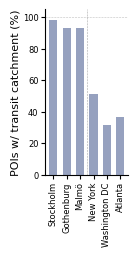


Saved: outputs/tables/catchment_coverage.csv

Catchment Coverage Summary:
         city  n_total  pct_with_catchment
     new_york   290270           50.950839
washington_dc    84650           31.404607
      atlanta   102181           36.262123
    Stockholm    35948           98.261378
        Malmö    12680           93.233438
     Göteborg    16806           92.758539


In [31]:
# Plot coverage (compact single-series version)
fig, ax = plt.subplots(figsize=(mm_to_inch(30), mm_to_inch(60)))

plot_cov = coverage_df[coverage_df['city'].isin(selected_cities)].copy()
plot_cov['display_city'] = plot_cov['city'].map(CITY_DISPLAY)

city_order = {c: i for i, c in enumerate(selected_cities)}
plot_cov = plot_cov.sort_values('city', key=lambda x: x.map(city_order))

x = np.arange(len(plot_cov))

# Use one coverage column only
bars = ax.bar(
    x,
    plot_cov['pct_with_catchment_birth'],
    width=0.6,
    color=COLORS['catchment'],
    alpha=0.85
)

# Compact formatting
ax.set_ylabel('POIs w/ transit catchment (%)')
ax.set_xticks(x)
ax.set_xticklabels(plot_cov['display_city'], rotation=90)
ax.tick_params(axis='y')
ax.set_ylim(0, 105)

# Light reference lines
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)
ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=0.4, alpha=0.7)

# Clean up without seaborn
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplots_adjust(left=0.28, right=0.98, bottom=0.28, top=0.98)

fig.savefig(
    'outputs/figures/fig1_0_catchment_coverage.pdf',
    dpi=600,
    facecolor="white"
)
plt.show()

# Save coverage table
coverage_df.to_csv(TABLE_DIR / 'catchment_coverage.csv', index=False)
print(f"\nSaved: {TABLE_DIR / 'catchment_coverage.csv'}")

print("\nCatchment Coverage Summary:")
print(
    coverage_df[coverage_df['city'].isin(selected_cities)][
        ['city', 'n_total', 'pct_with_catchment_birth']
    ].rename(columns={'pct_with_catchment_birth': 'pct_with_catchment'}).to_string(index=False)
)

## Figure 1a-b: Bar Charts by Catchment Regime (2x2 Layout)

Separate analysis for POIs with and without transit catchment data.

In [15]:
# =============================================================================
# Compute Statistics by Regime (With/Without Catchment)
# =============================================================================

def compute_city_stats_by_regime(df, city_col='city'):
    """Compute mean and std for mixing metrics by city, split by catchment availability."""
    stats = []
    
    for city in df[city_col].unique():
        city_df = df[df[city_col] == city]
        country = 'US' if city in US_CITIES else 'Sweden'
        
        for dim in ['birth', 'income']:
            res_col = f'residential_entropy_{dim}_norm'
            vis_col = f'visitor_entropy_{dim}_norm'
            cat_col = f'catchment_entropy_{dim}_norm'
            
            # Split by catchment availability
            has_catchment = city_df[cat_col].notna()
            df_with = city_df[has_catchment]
            df_without = city_df[~has_catchment]
            
            # With catchment
            if len(df_with) > 0:
                stats.append({
                    'city': city,
                    'country': country,
                    'dimension': dim,
                    'regime': 'with_catchment',
                    'n_pois': len(df_with),
                    'residential_mean': df_with[res_col].mean(),
                    'residential_std': df_with[res_col].std(),
                    'visitor_mean': df_with[vis_col].mean(),
                    'visitor_std': df_with[vis_col].std(),
                    'catchment_mean': df_with[cat_col].mean(),
                    'catchment_std': df_with[cat_col].std(),
                })
            
            # Without catchment
            if len(df_without) > 0:
                stats.append({
                    'city': city,
                    'country': country,
                    'dimension': dim,
                    'regime': 'without_catchment',
                    'n_pois': len(df_without),
                    'residential_mean': df_without[res_col].mean(),
                    'residential_std': df_without[res_col].std(),
                    'visitor_mean': df_without[vis_col].mean(),
                    'visitor_std': df_without[vis_col].std(),
                    'catchment_mean': np.nan,
                    'catchment_std': np.nan,
                })
    
    return pd.DataFrame(stats)

stats_by_regime = compute_city_stats_by_regime(all_pois)
print(f"Statistics computed: {len(stats_by_regime)} rows")
print(stats_by_regime[stats_by_regime['city'].isin(selected_cities)].groupby(['regime', 'dimension']).size())

Statistics computed: 84 rows
regime             dimension
with_catchment     birth        6
                   income       6
without_catchment  birth        6
                   income       6
dtype: int64


Saved: outputs/figures/fig1ab_mixing_by_regime.pdf
Saved: outputs/figures/fig1ab_mixing_by_regime.png


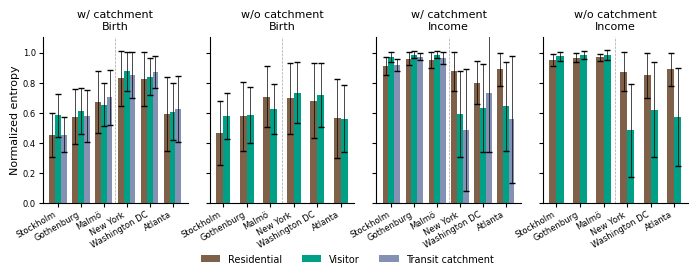

In [21]:
# =============================================================================
# Figure 1a-b: 1x4 Bar Charts (With/Without Catchment × Birth/Income)
# =============================================================================

fig, axes = plt.subplots(
    1, 4,
    figsize=(mm_to_inch(180), mm_to_inch(60)),
    sharey=True
)

cities = [CITY_DISPLAY.get(c, c) for c in selected_cities]
x = np.arange(len(cities))
width = 0.25

# Define panel structure explicitly (cleaner)
panels = [
    ('with_catchment', 'birth'),
    ('without_catchment', 'birth'),
    ('with_catchment', 'income'),
    ('without_catchment', 'income')
]

legend_handles = []
legend_labels = []

for idx, (regime, dim) in enumerate(panels):
    ax = axes[idx]

    # -------------------------------
    # Data prep
    # -------------------------------
    plot_data = stats_by_regime[
        (stats_by_regime['regime'] == regime) &
        (stats_by_regime['dimension'] == dim) &
        (stats_by_regime['city'].isin(selected_cities))
    ].copy()

    plot_data['display_city'] = plot_data['city'].map(CITY_DISPLAY)
    city_order = {CITY_DISPLAY.get(c, c): i for i, c in enumerate(selected_cities)}
    plot_data = plot_data.sort_values('display_city', key=lambda x: x.map(city_order))

    # Fill missing
    if len(plot_data) < len(selected_cities):
        for c in selected_cities:
            dc = CITY_DISPLAY.get(c, c)
            if dc not in plot_data['display_city'].values:
                plot_data = pd.concat([plot_data, pd.DataFrame([{
                    'city': c, 'display_city': dc, 'dimension': dim, 'regime': regime,
                    'residential_mean': np.nan, 'residential_std': np.nan,
                    'visitor_mean': np.nan, 'visitor_std': np.nan,
                    'catchment_mean': np.nan, 'catchment_std': np.nan
                }])], ignore_index=True)

        plot_data = plot_data.sort_values('display_city', key=lambda x: x.map(city_order))

    # -------------------------------
    # Plot bars
    # -------------------------------
    if regime == 'with_catchment':
        mtypes = ['residential', 'visitor', 'catchment']
        mlabels = ['Residential', 'Visitor', 'Transit catchment']
        mcolors = [COLORS['residential'], COLORS['visitor'], COLORS['catchment']]

        for i, (mtype, label, color) in enumerate(zip(mtypes, mlabels, mcolors)):
            bars = ax.bar(
                x + (i - 1) * width,
                plot_data[f'{mtype}_mean'].values,
                width,
                yerr=plot_data[f'{mtype}_std'].values,
                color=color,
                capsize=2,
                error_kw={'linewidth': 0.5},
                label=label
            )

            if idx == 0:  # collect legend only once
                legend_handles.append(bars[0])
                legend_labels.append(label)

    else:
        mtypes = ['residential', 'visitor']
        mlabels = ['Residential', 'Visitor']
        mcolors = [COLORS['residential'], COLORS['visitor']]
        width_2 = 0.3

        for i, (mtype, label, color) in enumerate(zip(mtypes, mlabels, mcolors)):
            bars = ax.bar(
                x + (i - 0.5) * width_2,
                plot_data[f'{mtype}_mean'].values,
                width_2,
                yerr=plot_data[f'{mtype}_std'].values,
                color=color,
                capsize=2,
                error_kw={'linewidth': 0.5},
                label=label
            )

            if idx == 0:
                legend_handles.append(bars[0])
                legend_labels.append(label)

    # -------------------------------
    # Axes formatting
    # -------------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(cities, rotation=30, ha='right')
    ax.set_ylim(0, 1.1)

    # Vertical separator (Sweden vs US)
    ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

    # Titles
    regime_label = 'w/ catchment' if regime == 'with_catchment' else 'w/o catchment'
    dim_label = 'Birth' if dim == 'birth' else 'Income'
    ax.set_title(f"{regime_label}\n{dim_label}")

    # Y label only on first
    if idx == 0:
        ax.set_ylabel('Normalized entropy')

# -------------------------------
# Global horizontal legend (BOTTOM)
# -------------------------------
fig.legend(
    legend_handles,
    legend_labels,
    loc='upper center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02)
)

# -------------------------------
# Layout tuning (CRUCIAL)
# -------------------------------
plt.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.90,
    bottom=0.20,   # <-- space for legend
    wspace=0.15
)

save_figure(fig, 'fig1ab_mixing_by_regime')
plt.show()

## Diversity Comparison: With vs Without Transit Catchment

Compare the visitor-residential diversity gap between POIs with and without transit catchment data.

In [7]:
# =============================================================================
# Comparison Table: Visitor vs Residential Diversity by Catchment Regime
# With Statistical Significance Tests
# =============================================================================

import pyperclip
from scipy import stats

def sig_marker(p):
    """Return significance marker."""
    if pd.isna(p): return ''
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def sig_marker_latex(p):
    """Return significance marker for LaTeX."""
    if pd.isna(p): return ''
    if p < 0.001: return '$^{***}$'
    if p < 0.01: return '$^{**}$'
    if p < 0.05: return '$^{*}$'
    return '$^{ns}$'

def compute_diversity_comparison_with_stats(city_df, dimension='birth'):
    """
    Compute diversity differences with statistical tests:
    1. Wilcoxon signed-rank test for vis vs res within each regime
    2. Return raw differences for between-regime comparison
    """
    res_col = f'residential_entropy_{dimension}_norm'
    vis_col = f'visitor_entropy_{dimension}_norm'
    cat_col = f'catchment_entropy_{dimension}_norm'

    # Split by catchment availability
    has_catchment = city_df[cat_col].notna()
    df_with = city_df[has_catchment]
    df_without = city_df[~has_catchment]

    results = {}

    # With catchment
    valid_with = df_with[[res_col, vis_col]].dropna()
    if len(valid_with) >= 20:
        diff_with = (valid_with[vis_col] - valid_with[res_col]).values
        try:
            _, p_wilcox = stats.wilcoxon(valid_with[vis_col], valid_with[res_col])
        except:
            p_wilcox = np.nan

        results['with'] = {
            'n': len(valid_with),
            'res_mean': valid_with[res_col].mean(),
            'vis_mean': valid_with[vis_col].mean(),
            'diff_mean': diff_with.mean(),
            'diff_std': diff_with.std(),
            'diff_median': np.median(diff_with),
            'p_wilcox': p_wilcox,
            'diff_array': diff_with,
        }
    else:
        results['with'] = {'n': len(valid_with)}

    # Without catchment
    valid_without = df_without[[res_col, vis_col]].dropna()
    if len(valid_without) >= 20:
        diff_without = (valid_without[vis_col] - valid_without[res_col]).values
        try:
            _, p_wilcox = stats.wilcoxon(valid_without[vis_col], valid_without[res_col])
        except:
            p_wilcox = np.nan

        results['without'] = {
            'n': len(valid_without),
            'res_mean': valid_without[res_col].mean(),
            'vis_mean': valid_without[vis_col].mean(),
            'diff_mean': diff_without.mean(),
            'diff_std': diff_without.std(),
            'diff_median': np.median(diff_without),
            'p_wilcox': p_wilcox,
            'diff_array': diff_without,
        }
    else:
        results['without'] = {'n': len(valid_without)}

    # Difference-of-differences: Mann-Whitney U test
    if 'diff_array' in results.get('with', {}) and 'diff_array' in results.get('without', {}):
        try:
            _, p_mannwhitney = stats.mannwhitneyu(
                results['with']['diff_array'],
                results['without']['diff_array'],
                alternative='two-sided'
            )
            results['diff_of_diff'] = {
                'with_mean': results['with']['diff_mean'],
                'without_mean': results['without']['diff_mean'],
                'delta': results['with']['diff_mean'] - results['without']['diff_mean'],
                'p_mannwhitney': p_mannwhitney,
            }
        except:
            results['diff_of_diff'] = {'p_mannwhitney': np.nan}

    return results

# Compute comparison for all cities
comparison_rows = []
diff_of_diff_rows = []

for city in selected_cities:
    city_df = all_pois[all_pois['city'] == city]
    display_name = CITY_DISPLAY.get(city, city)
    country = 'US' if city in US_CITIES else 'Sweden'

    for dim in ['birth', 'income']:
        result = compute_diversity_comparison_with_stats(city_df, dim)

        for regime in ['with', 'without']:
            r = result.get(regime, {})
            if 'diff_mean' in r:
                comparison_rows.append({
                    'City': display_name,
                    'Country': country,
                    'Dimension': dim.capitalize(),
                    'Regime': 'With Catchment' if regime == 'with' else 'Without Catchment',
                    'N': r['n'],
                    'Res. Mean': r['res_mean'],
                    'Vis. Mean': r['vis_mean'],
                    'Vis-Res Diff': r['diff_mean'],
                    'Diff Std': r['diff_std'],
                    'p_wilcox': r['p_wilcox'],
                })

        if 'diff_of_diff' in result:
            dod = result['diff_of_diff']
            diff_of_diff_rows.append({
                'City': display_name,
                'Country': country,
                'Dimension': dim.capitalize(),
                'Diff (with)': dod.get('with_mean', np.nan),
                'Diff (without)': dod.get('without_mean', np.nan),
                'Delta': dod.get('delta', np.nan),
                'p_mannwhitney': dod.get('p_mannwhitney', np.nan),
            })

comparison_df = pd.DataFrame(comparison_rows)
diff_of_diff_df = pd.DataFrame(diff_of_diff_rows)

# Display table
print("=" * 140)
print("DIVERSITY COMPARISON: Visitor - Residential by Catchment Regime (with Statistical Tests)")
print("=" * 140)
print("\nWithin-regime test: Wilcoxon signed-rank (paired, vis vs res)")
print("Between-regime test: Mann-Whitney U (independent, comparing vis-res differences)\n")

for dim in ['Birth', 'Income']:
    print(f"\n{'='*60}")
    print(f"  {dim} Dimension")
    print(f"{'='*60}\n")
    print(f"{'City':<14} {'Ctry':<6} | {'With Catchment':^40} | {'Without Catchment':^40} | {'Diff-of-Diff':^18}")
    print(f"{'':<14} {'':<6} | {'N':>8} {'Res':>7} {'Vis':>7} {'Diff':>14} | {'N':>8} {'Res':>7} {'Vis':>7} {'Diff':>14} | {'Delta':>10} {'p':>6}")
    print("-" * 140)

    dim_comp = comparison_df[comparison_df['Dimension'] == dim]
    dim_dod = diff_of_diff_df[diff_of_diff_df['Dimension'] == dim]

    for city in [CITY_DISPLAY.get(c, c) for c in selected_cities]:
        city_comp = dim_comp[dim_comp['City'] == city]
        city_dod = dim_dod[dim_dod['City'] == city]

        with_data = city_comp[city_comp['Regime'] == 'With Catchment']
        without_data = city_comp[city_comp['Regime'] == 'Without Catchment']

        country = with_data['Country'].values[0] if len(with_data) > 0 else (
            without_data['Country'].values[0] if len(without_data) > 0 else '')

        if len(with_data) > 0:
            w = with_data.iloc[0]
            with_str = f"{int(w['N']):>8,} {w['Res. Mean']:>7.3f} {w['Vis. Mean']:>7.3f} {w['Vis-Res Diff']:>+.3f}{sig_marker(w['p_wilcox']):>5}"
        else:
            with_str = f"{'--':>8} {'--':>7} {'--':>7} {'--':>14}"

        if len(without_data) > 0:
            wo = without_data.iloc[0]
            without_str = f"{int(wo['N']):>8,} {wo['Res. Mean']:>7.3f} {wo['Vis. Mean']:>7.3f} {wo['Vis-Res Diff']:>+.3f}{sig_marker(wo['p_wilcox']):>5}"
        else:
            without_str = f"{'--':>8} {'--':>7} {'--':>7} {'--':>14}"

        if len(city_dod) > 0:
            dod = city_dod.iloc[0]
            dod_str = f"{dod['Delta']:>+10.3f} {sig_marker(dod['p_mannwhitney']):>6}"
        else:
            dod_str = f"{'--':>10} {'--':>6}"

        print(f"{city:<14} {country:<6} | {with_str} | {without_str} | {dod_str}")

print("\n*** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print("Diff column: Wilcoxon p-value for vis vs res within regime")
print("Delta column: (Diff_with - Diff_without), Mann-Whitney U p-value")

# Save to CSV
comparison_df.to_csv(TABLE_DIR / 'diversity_comparison_by_regime.csv', index=False)
diff_of_diff_df.to_csv(TABLE_DIR / 'diversity_diff_of_diff.csv', index=False)
print(f"\nSaved: {TABLE_DIR / 'diversity_comparison_by_regime.csv'}")
print(f"Saved: {TABLE_DIR / 'diversity_diff_of_diff.csv'}")

# Generate LaTeX table
def generate_latex_comparison_table_with_stats(comp_df, dod_df):
    latex_lines = []
    latex_lines.append(r"\begin{table}[htbp]")
    latex_lines.append(r"\centering")
    latex_lines.append(r"\caption{Visitor vs. Residential Diversity by Transit Catchment Regime}")
    latex_lines.append(r"\label{tab:diversity_comparison}")
    latex_lines.append(r"\footnotesize")
    latex_lines.append(r"\begin{tabular}{llrrrc|rrrc|cc}")
    latex_lines.append(r"\toprule")
    latex_lines.append(r" & & \multicolumn{4}{c}{With Catchment} & \multicolumn{4}{c}{Without Catchment} & \multicolumn{2}{c}{Diff-of-Diff} \\")
    latex_lines.append(r"\cmidrule(lr){3-6} \cmidrule(lr){7-10} \cmidrule(lr){11-12}")
    latex_lines.append(r"City & Dim. & N & Res. & Vis. & Diff. & N & Res. & Vis. & Diff. & $\Delta$ & p \\")
    latex_lines.append(r"\midrule")

    for city in [CITY_DISPLAY.get(c, c) for c in selected_cities]:
        city_comp = comp_df[comp_df['City'] == city]
        city_dod = dod_df[dod_df['City'] == city]

        for dim in ['Birth', 'Income']:
            dim_comp = city_comp[city_comp['Dimension'] == dim]
            dim_dod = city_dod[city_dod['Dimension'] == dim]

            with_data = dim_comp[dim_comp['Regime'] == 'With Catchment']
            without_data = dim_comp[dim_comp['Regime'] == 'Without Catchment']

            city_label = city if dim == 'Birth' else ''

            if len(with_data) > 0:
                w = with_data.iloc[0]
                with_vals = f"{int(w['N']):,} & {w['Res. Mean']:.3f} & {w['Vis. Mean']:.3f} & {w['Vis-Res Diff']:+.3f}{sig_marker_latex(w['p_wilcox'])}"
            else:
                with_vals = r"-- & -- & -- & --"

            if len(without_data) > 0:
                wo = without_data.iloc[0]
                without_vals = f"{int(wo['N']):,} & {wo['Res. Mean']:.3f} & {wo['Vis. Mean']:.3f} & {wo['Vis-Res Diff']:+.3f}{sig_marker_latex(wo['p_wilcox'])}"
            else:
                without_vals = r"-- & -- & -- & --"

            if len(dim_dod) > 0:
                dod = dim_dod.iloc[0]
                dod_vals = f"{dod['Delta']:+.3f} & {sig_marker_latex(dod['p_mannwhitney']).replace('$', '')}"
            else:
                dod_vals = r"-- & --"

            latex_lines.append(f"{city_label} & {dim} & {with_vals} & {without_vals} & {dod_vals} \\\\")

        if city != CITY_DISPLAY.get(selected_cities[-1], selected_cities[-1]):
            latex_lines.append(r"\addlinespace[2pt]")

    latex_lines.append(r"\bottomrule")
    latex_lines.append(r"\end{tabular}")
    latex_lines.append(r"\\[5pt]")
    latex_lines.append(r"\raggedright\footnotesize{Diff.: Wilcoxon signed-rank test (vis vs res within regime). $\Delta$: difference-of-differences (with $-$ without), Mann-Whitney U test.}")
    latex_lines.append(r"\\")
    latex_lines.append(r"\raggedright\footnotesize{$^{***}p<0.001$, $^{**}p<0.01$, $^{*}p<0.05$, $^{ns}$not significant.}")
    latex_lines.append(r"\end{table}")

    return '\n'.join(latex_lines)

latex_table = generate_latex_comparison_table_with_stats(comparison_df, diff_of_diff_df)
try:
    pyperclip.copy(latex_table)
    print("\nLaTeX table copied to clipboard!")
except:
    print("\nCould not copy to clipboard. LaTeX table:")
    print(latex_table)

DIVERSITY COMPARISON: Visitor - Residential by Catchment Regime (with Statistical Tests)

Within-regime test: Wilcoxon signed-rank (paired, vis vs res)
Between-regime test: Mann-Whitney U (independent, comparing vis-res differences)


  Birth Dimension

City           Ctry   |              With Catchment              |            Without Catchment             |    Diff-of-Diff   
                      |        N     Res     Vis           Diff |        N     Res     Vis           Diff |      Delta      p
--------------------------------------------------------------------------------------------------------------------------------------------
Stockholm      Sweden |   35,323   0.453   0.583 +0.130  *** |      625   0.464   0.576 +0.112  *** |     +0.017     ns
Gothenburg     Sweden |   15,589   0.573   0.608 +0.035  *** |    1,217   0.576   0.584 +0.008   ns |     +0.026    ***
Malmö          Sweden |   11,822   0.670   0.654 -0.016  *** |      858   0.707   0.624 -0.083  *** |     +0.0

## Statistical Tests: Pairwise Comparisons by Catchment Regime

In [8]:
# =============================================================================
# Statistical Tests: W/ Transit Catchment Analysis
# =============================================================================
# 1. Within w/ catchment: res vs vis, res vs cat, (vis-res) vs (cat-res)
# 2. Between regimes: residential diversity comparison (w/ vs w/o catchment)
# =============================================================================

from scipy import stats
import pyperclip

def sig_marker(p):
    if pd.isna(p): return ''
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

def sig_marker_latex(p):
    if pd.isna(p): return ''
    if p < 0.001: return '$^{***}$'
    if p < 0.01: return '$^{**}$'
    if p < 0.05: return '$^{*}$'
    return '$^{ns}$'

def compute_with_catchment_tests(city_df, dimension='birth'):
    """
    Compute tests for POIs WITH transit catchment:
    1. res vs vis (Wilcoxon signed-rank)
    2. res vs cat (Wilcoxon signed-rank)
    3. (vis-res) vs (cat-res) (Wilcoxon signed-rank on differences)
    """
    res_col = f'residential_entropy_{dimension}_norm'
    vis_col = f'visitor_entropy_{dimension}_norm'
    cat_col = f'catchment_entropy_{dimension}_norm'

    # Filter to POIs with catchment
    has_catchment = city_df[cat_col].notna()
    df_with = city_df[has_catchment]

    valid = df_with[[res_col, vis_col, cat_col]].dropna()
    n = len(valid)

    results = {'n': n}

    if n >= 20:
        res_vals = valid[res_col]
        vis_vals = valid[vis_col]
        cat_vals = valid[cat_col]

        results['res_mean'] = res_vals.mean()
        results['vis_mean'] = vis_vals.mean()
        results['cat_mean'] = cat_vals.mean()

        # Test 1: res vs vis
        try:
            _, p_vis_res = stats.wilcoxon(vis_vals, res_vals)
            results['vis_res_diff'] = (vis_vals - res_vals).mean()
            results['vis_res_p'] = p_vis_res
        except:
            results['vis_res_diff'] = np.nan
            results['vis_res_p'] = np.nan

        # Test 2: res vs cat
        try:
            _, p_cat_res = stats.wilcoxon(cat_vals, res_vals)
            results['cat_res_diff'] = (cat_vals - res_vals).mean()
            results['cat_res_p'] = p_cat_res
        except:
            results['cat_res_diff'] = np.nan
            results['cat_res_p'] = np.nan

        # Test 3: (vis-res) vs (cat-res) - diff of diff
        # Equivalent to testing vis vs cat
        try:
            diff_vis_res = vis_vals - res_vals
            diff_cat_res = cat_vals - res_vals
            _, p_diff_diff = stats.wilcoxon(diff_vis_res, diff_cat_res)
            results['diff_of_diff'] = diff_vis_res.mean() - diff_cat_res.mean()
            results['diff_of_diff_p'] = p_diff_diff
        except:
            results['diff_of_diff'] = np.nan
            results['diff_of_diff_p'] = np.nan

    return results

def compute_residential_between_regimes(city_df, dimension='birth'):
    """
    Compare residential diversity between w/ and w/o catchment POIs.
    Uses Mann-Whitney U test (independent samples).
    """
    res_col = f'residential_entropy_{dimension}_norm'
    cat_col = f'catchment_entropy_{dimension}_norm'

    # Split by catchment availability
    has_catchment = city_df[cat_col].notna()
    df_with = city_df[has_catchment]
    df_without = city_df[~has_catchment]

    res_with = df_with[res_col].dropna()
    res_without = df_without[res_col].dropna()

    results = {
        'n_with': len(res_with),
        'n_without': len(res_without),
    }

    if len(res_with) >= 20 and len(res_without) >= 20:
        results['res_mean_with'] = res_with.mean()
        results['res_mean_without'] = res_without.mean()
        results['res_diff'] = res_with.mean() - res_without.mean()

        try:
            _, p_mw = stats.mannwhitneyu(res_with, res_without, alternative='two-sided')
            results['p_mannwhitney'] = p_mw
        except:
            results['p_mannwhitney'] = np.nan

    return results

# =============================================================================
# Part 1: W/ Catchment Tests (res-vis, res-cat, diff-of-diff)
# =============================================================================
print("=" * 120)
print("PART 1: Statistical Tests for POIs WITH Transit Catchment")
print("=" * 120)
print("\nTests: (1) Vis vs Res, (2) Cat vs Res, (3) (Vis-Res) vs (Cat-Res)")
print("Method: Wilcoxon signed-rank test (paired samples)\n")

print(f"{'City':<16} {'Dim':<8} {'N':>8} {'Res':>7} {'Vis':>7} {'Cat':>7} | {'Vis-Res':>14} {'Cat-Res':>14} {'DiffOfDiff':>14}")
print("-" * 120)

with_catchment_results = []

for city in selected_cities:
    city_df = all_pois[all_pois['city'] == city]
    display_name = CITY_DISPLAY.get(city, city)
    country = 'US' if city in US_CITIES else 'Sweden'

    for dim in ['birth', 'income']:
        r = compute_with_catchment_tests(city_df, dim)

        if 'res_mean' in r:
            with_catchment_results.append({
                'city': display_name,
                'country': country,
                'dimension': dim.capitalize(),
                **r
            })

            vr_str = f"{r['vis_res_diff']:+.3f}{sig_marker(r['vis_res_p']):>4}"
            cr_str = f"{r['cat_res_diff']:+.3f}{sig_marker(r['cat_res_p']):>4}"
            dd_str = f"{r['diff_of_diff']:+.3f}{sig_marker(r['diff_of_diff_p']):>4}"

            print(f"{display_name:<16} {dim.capitalize():<8} {r['n']:>8,} {r['res_mean']:>7.3f} {r['vis_mean']:>7.3f} {r['cat_mean']:>7.3f} | {vr_str:>14} {cr_str:>14} {dd_str:>14}")
        else:
            print(f"{display_name:<16} {dim.capitalize():<8} {r['n']:>8,} -- insufficient data --")

with_catchment_df = pd.DataFrame(with_catchment_results)

# =============================================================================
# Part 2: Residential Diversity Comparison (w/ vs w/o catchment)
# =============================================================================
print("\n" + "=" * 120)
print("PART 2: Residential Diversity Comparison (w/ vs w/o Catchment POIs)")
print("=" * 120)
print("\nMethod: Mann-Whitney U test (independent samples)\n")

print(f"{'City':<16} {'Dim':<8} | {'N (w/)':>10} {'Res (w/)':>10} | {'N (w/o)':>10} {'Res (w/o)':>10} | {'Diff':>10} {'p':>8}")
print("-" * 100)

residential_comparison_results = []

for city in selected_cities:
    city_df = all_pois[all_pois['city'] == city]
    display_name = CITY_DISPLAY.get(city, city)
    country = 'US' if city in US_CITIES else 'Sweden'

    for dim in ['birth', 'income']:
        r = compute_residential_between_regimes(city_df, dim)

        if 'res_mean_with' in r:
            residential_comparison_results.append({
                'city': display_name,
                'country': country,
                'dimension': dim.capitalize(),
                **r
            })

            diff_str = f"{r['res_diff']:+.3f}"
            p_str = sig_marker(r['p_mannwhitney'])

            print(f"{display_name:<16} {dim.capitalize():<8} | {r['n_with']:>10,} {r['res_mean_with']:>10.3f} | {r['n_without']:>10,} {r['res_mean_without']:>10.3f} | {diff_str:>10} {p_str:>8}")
        else:
            print(f"{display_name:<16} {dim.capitalize():<8} | {r['n_with']:>10,} {'--':>10} | {r['n_without']:>10,} {'--':>10} | {'--':>10} {'--':>8}")

residential_comparison_df = pd.DataFrame(residential_comparison_results)

print("\n*** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

# Save results
with_catchment_df.to_csv(TABLE_DIR / 'stat_with_catchment_tests.csv', index=False)
residential_comparison_df.to_csv(TABLE_DIR / 'stat_residential_comparison.csv', index=False)
print(f"\nSaved: {TABLE_DIR / 'stat_with_catchment_tests.csv'}")
print(f"Saved: {TABLE_DIR / 'stat_residential_comparison.csv'}")

# =============================================================================
# Generate LaTeX Tables
# =============================================================================

def generate_latex_with_catchment_table(df):
    """Generate LaTeX table for w/ catchment tests."""
    latex_lines = []
    latex_lines.append(r"\begin{table}[htbp]")
    latex_lines.append(r"\centering")
    latex_lines.append(r"\caption{Diversity Comparisons for POIs with Transit Catchment (Wilcoxon Signed-Rank Tests)}")
    latex_lines.append(r"\label{tab:with_catchment_tests}")
    latex_lines.append(r"\footnotesize")
    latex_lines.append(r"\begin{tabular}{llrrrrccc}")
    latex_lines.append(r"\toprule")
    latex_lines.append(r"City & Dim. & N & Res. & Vis. & Cat. & Vis$-$Res & Cat$-$Res & $\Delta$ \\")
    latex_lines.append(r"\midrule")

    for city in [CITY_DISPLAY.get(c, c) for c in selected_cities]:
        city_data = df[df['city'] == city]
        for dim in ['Birth', 'Income']:
            row = city_data[city_data['dimension'] == dim]
            if len(row) > 0:
                r = row.iloc[0]
                city_label = city if dim == 'Birth' else ''
                vr_val = f"{r['vis_res_diff']:+.3f}{sig_marker_latex(r['vis_res_p'])}"
                cr_val = f"{r['cat_res_diff']:+.3f}{sig_marker_latex(r['cat_res_p'])}"
                dd_val = f"{r['diff_of_diff']:+.3f}{sig_marker_latex(r['diff_of_diff_p'])}"
                latex_lines.append(f"{city_label} & {dim} & {int(r['n']):,} & {r['res_mean']:.3f} & {r['vis_mean']:.3f} & {r['cat_mean']:.3f} & {vr_val} & {cr_val} & {dd_val} \\\\")
        if city != CITY_DISPLAY.get(selected_cities[-1], selected_cities[-1]):
            latex_lines.append(r"\addlinespace[2pt]")

    latex_lines.append(r"\bottomrule")
    latex_lines.append(r"\end{tabular}")
    latex_lines.append(r"\\[5pt]")
    latex_lines.append(r"\raggedright\footnotesize{$\Delta$ = (Vis$-$Res) $-$ (Cat$-$Res). $^{***}p<0.001$, $^{**}p<0.01$, $^{*}p<0.05$, $^{ns}$not significant.}")
    latex_lines.append(r"\end{table}")
    return '\n'.join(latex_lines)

def generate_latex_residential_comparison_table(df):
    """Generate LaTeX table for residential comparison between regimes."""
    latex_lines = []
    latex_lines.append(r"\begin{table}[htbp]")
    latex_lines.append(r"\centering")
    latex_lines.append(r"\caption{Residential Diversity Comparison: POIs with vs without Transit Catchment (Mann-Whitney U Tests)}")
    latex_lines.append(r"\label{tab:residential_comparison}")
    latex_lines.append(r"\footnotesize")
    latex_lines.append(r"\begin{tabular}{llrrrrrr}")
    latex_lines.append(r"\toprule")
    latex_lines.append(r" & & \multicolumn{2}{c}{w/ Catchment} & \multicolumn{2}{c}{w/o Catchment} & & \\")
    latex_lines.append(r"\cmidrule(lr){3-4} \cmidrule(lr){5-6}")
    latex_lines.append(r"City & Dim. & N & Res. & N & Res. & Diff. & p \\")
    latex_lines.append(r"\midrule")

    for city in [CITY_DISPLAY.get(c, c) for c in selected_cities]:
        city_data = df[df['city'] == city]
        for dim in ['Birth', 'Income']:
            row = city_data[city_data['dimension'] == dim]
            if len(row) > 0:
                r = row.iloc[0]
                city_label = city if dim == 'Birth' else ''
                diff_val = f"{r['res_diff']:+.3f}"
                p_val = sig_marker_latex(r['p_mannwhitney'])
                latex_lines.append(f"{city_label} & {dim} & {int(r['n_with']):,} & {r['res_mean_with']:.3f} & {int(r['n_without']):,} & {r['res_mean_without']:.3f} & {diff_val} & {p_val} \\\\")
        if city != CITY_DISPLAY.get(selected_cities[-1], selected_cities[-1]):
            latex_lines.append(r"\addlinespace[2pt]")

    latex_lines.append(r"\bottomrule")
    latex_lines.append(r"\end{tabular}")
    latex_lines.append(r"\\[5pt]")
    latex_lines.append(r"\raggedright\footnotesize{Diff. = Res.(w/) $-$ Res.(w/o). $^{***}p<0.001$, $^{**}p<0.01$, $^{*}p<0.05$, $^{ns}$not significant.}")
    latex_lines.append(r"\end{table}")
    return '\n'.join(latex_lines)

latex_with_catchment = generate_latex_with_catchment_table(with_catchment_df)
latex_residential = generate_latex_residential_comparison_table(residential_comparison_df)

# Combine both tables
combined_latex = latex_with_catchment + "\n\n" + latex_residential

try:
    pyperclip.copy(combined_latex)
    print("\nBoth LaTeX tables copied to clipboard!")
except:
    print("\nCould not copy to clipboard. LaTeX tables:")
    print(combined_latex)

PART 1: Statistical Tests for POIs WITH Transit Catchment

Tests: (1) Vis vs Res, (2) Cat vs Res, (3) (Vis-Res) vs (Cat-Res)
Method: Wilcoxon signed-rank test (paired samples)

City             Dim             N     Res     Vis     Cat |        Vis-Res        Cat-Res     DiffOfDiff
------------------------------------------------------------------------------------------------------------------------
Stockholm        Birth      35,323   0.453   0.583   0.453 |     +0.130 ***     +0.000 ***     +0.130 ***
Stockholm        Income     35,323   0.911   0.972   0.919 |     +0.061 ***     +0.008 ***     +0.053 ***
Gothenburg       Birth      15,589   0.573   0.608   0.581 |     +0.035 ***     +0.007 ***     +0.027 ***
Gothenburg       Income     15,589   0.960   0.986   0.972 |     +0.026 ***     +0.012 ***     +0.014 ***
Malmö            Birth      11,822   0.670   0.654   0.701 |     -0.016 ***     +0.031 ***     -0.047 ***
Malmö            Income     11,822   0.951   0.986   0.964 |     +

## Supplementary Figure 1: Error Bar Plots (Top 10 Sweden + 3 US)

In [9]:
# Expanded comparison showing uncertainty
# Get top 10 Sweden by POI count
sweden_stats = city_stats[city_stats['country'] == 'Sweden'].nlargest(10, 'n_pois')
us_stats = city_stats[city_stats['country'] == 'US']
fig2_data = pd.concat([sweden_stats, us_stats]).copy()
fig2_data['display_name'] = fig2_data['city'].map(lambda x: CITY_DISPLAY.get(x, x))

### S Figure 1a

In [ ]:
fig = plt.figure(figsize=(mm_to_inch(90), mm_to_inch(90)))
# Sort by visitor diversity (descending)
fig2_data_birth = fig2_data.sort_values('visitor_birth_mean', ascending=True)
fig2_data_income = fig2_data.sort_values('visitor_income_mean', ascending=True)

# Panel (a): Birth dimension
ax = fig.add_subplot(1,1,1)
y_pos = np.arange(len(fig2_data_birth))
offset = 0.25

for i, (mtype, label, color) in enumerate(zip(mixing_types, mixing_labels, mixing_colors)):
    means = fig2_data_birth[f'{mtype}_birth_mean'].values
    stds = fig2_data_birth[f'{mtype}_birth_std'].values
    ax.errorbar(means, y_pos + (i-1)*offset, xerr=stds, fmt='o', markersize=4,
                color=color, capsize=2, capthick=0.6, elinewidth=0.6, label=label)

ax.set_yticks(y_pos)
ax.set_yticklabels(fig2_data_birth['display_name'])
ax.set_xlabel('Normalized entropy')
ax.set_title('Birth background')
ax.set_xlim(0.3, 1.05)
ax.legend(loc='lower right')

# Color y-labels by country
for i, (_, row) in enumerate(fig2_data_birth.iterrows()):
    color = COLORS['US'] if row['country'] == 'US' else COLORS['Sweden']
    ax.get_yticklabels()[i].set_color(color)
fig.savefig(f"outputs/figures/sfig1_mixing_overview_a.pdf", dpi=600, facecolor="white")

### S Figure 1b

In [ ]:
fig = plt.figure(figsize=(mm_to_inch(90), mm_to_inch(90)))
# Panel (b): Income dimension
ax = fig.add_subplot(1,1,1)
y_pos = np.arange(len(fig2_data_income))

for i, (mtype, label, color) in enumerate(zip(mixing_types, mixing_labels, mixing_colors)):
    means = fig2_data_income[f'{mtype}_income_mean'].values
    stds = fig2_data_income[f'{mtype}_income_std'].values
    ax.errorbar(means, y_pos + (i-1)*offset, xerr=stds, fmt='o', markersize=4,
                color=color, capsize=2, capthick=0.6, elinewidth=0.6, label=label)

ax.set_yticks(y_pos)
ax.set_yticklabels(fig2_data_income['display_name'])
ax.set_xlabel('Normalized entropy')
ax.set_title('Income')
ax.set_xlim(0, 1.05)

# Color y-labels by country
for i, (_, row) in enumerate(fig2_data_income.iterrows()):
    color = COLORS['US'] if row['country'] == 'US' else COLORS['Sweden']
    ax.get_yticklabels()[i].set_color(color)
fig.savefig(f"outputs/figures/sfig1_mixing_overview_b.pdf", dpi=600, facecolor="white")

## Figure 1c-d Bivariate spatial maps

In [10]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import box

def city_bounds_to_3857(city_name):
    """
    Convert CITY_BOUNDS[city_name] from
    [lat_min, lat_max, lon_min, lon_max]
    to projected bounds:
    (xmin, xmax, ymin, ymax)
    """
    lat_min, lat_max, lon_min, lon_max = CITY_BOUNDS[city_name]

    bbox = gpd.GeoSeries(
        [box(lon_min, lat_min, lon_max, lat_max)],
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    xmin, ymin, xmax, ymax = bbox.total_bounds
    return xmin, xmax, ymin, ymax

In [55]:
def plot_birth_bivariate_row(
    x_col,
    row_label,
    selected_cities,
    all_pois,
    city_label_y=0.77,
    city_label_rotation=0,
    show_city_labels=True,
    show_title=True,
    title_lb="Birth background"
):
    ncols = len(selected_cities)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=ncols,
        figsize=(mm_to_inch(150), mm_to_inch(48)),
        constrained_layout=False
    )

    axes = np.atleast_1d(axes)

    # -------------------------------
    # Main title
    # -------------------------------
    if show_title:
        fig.text(
            0.5, 0.93,
            title_lb,
            ha="center",
            va="top"
        )

    for col_idx, city in enumerate(selected_cities):
        ax = axes[col_idx]

        city_df = all_pois[all_pois["city"] == city].copy()
        city_df = gpd.GeoDataFrame(
            city_df,
            geometry=gpd.points_from_xy(city_df["lon"], city_df["lat"]),
            crs="EPSG:4326"
        ).to_crs(epsg=3857)

        if city_df.empty:
            ax.text(
                0.5, 0.5, "No data",
                ha="center", va="center",
                transform=ax.transAxes
            )
            ax.axis("off")
            continue

        # predefined city extent
        extent = city_bounds_to_3857(city)

        plot_bivariate_map(
            ax,
            city_df,
            x_col,
            "visitor_entropy_birth_norm",
            bounds=extent
        )

        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_box_aspect(1)
        ax.axis("off")

    # -------------------------------
    # Global layout
    # -------------------------------
    plt.subplots_adjust(
        left=0.07,
        right=0.96,   # leave space for right-side row label
        bottom=0.08,
        top=0.78,
        wspace=0
    )

    # -------------------------------
    # City labels (mutable)
    # -------------------------------
    if show_city_labels:
        for col_idx, city in enumerate(selected_cities):
            bbox = axes[col_idx].get_position()
            x_center = bbox.x0 + bbox.width / 2

            fig.text(
                x_center,
                city_label_y,
                CITY_DISPLAY.get(city, city),
                ha="center",
                va="bottom",
                rotation=city_label_rotation
            )

    # -------------------------------
    # Row label on left side
    # -------------------------------
    fig.text(
        0.03,                # left side
        0.5,
        row_label,
        ha="left",
        va="center",
        rotation=90         # vertical, readable bottom→top
    )

    return fig

In [53]:
from matplotlib.patches import Rectangle
import numpy as np

def plot_bivariate_legend(
    xlabel="Residential",
    ylabel="Visitor",
    outfile=None,
    figsize=(mm_to_inch(30), mm_to_inch(30))
):
    """
    Plot a standalone 3x3 bivariate legend.

    Parameters
    ----------
    xlabel : str
        Label for x dimension
    ylabel : str
        Label for y dimension
    outfile : str or None
        If given, save to this file
    figsize : tuple
        Figure size in inches
    """
    colors_matrix = create_bivariate_colormap()

    fig, ax = plt.subplots(figsize=figsize)

    # draw 3x3 grid
    for y in range(3):
        for x in range(3):
            ax.add_patch(
                Rectangle(
                    (x, y),
                    1, 1,
                    facecolor=colors_matrix[y][x],
                    edgecolor="none"
                )
            )

    # formatting
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    # remove frame
    for spine in ax.spines.values():
        spine.set_visible(False)

    # axis arrows / labels
    ax.annotate(
        "", xy=(3.1, 0), xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", lw=0.8, color="black"),
        annotation_clip=False
    )
    ax.annotate(
        "", xy=(0, 3.1), xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", lw=0.8, color="black"),
        annotation_clip=False
    )

    ax.text(1.5, -0.35, xlabel, ha="center", va="top")
    ax.text(-0.35, 1.5, ylabel, ha="right", va="center", rotation=90)

    # optional low/high hints
    ax.text(0, -0.12, "Low", ha="left", va="top")
    ax.text(3, -0.12, "High", ha="right", va="top")
    ax.text(-0.12, 0, "Low", ha="right", va="bottom", rotation=90)
    ax.text(-0.12, 3, "High", ha="right", va="top", rotation=90)

    plt.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.99)

    if outfile:
        fig.savefig(outfile, dpi=600, facecolor="white")
    return fig

### Birth background

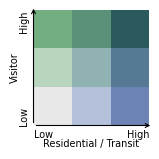

In [54]:
fig_leg = plot_bivariate_legend(
    xlabel="Residential / Transit",
    ylabel="Visitor",
    outfile="outputs/figures/bivariate_legend.pdf"
)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


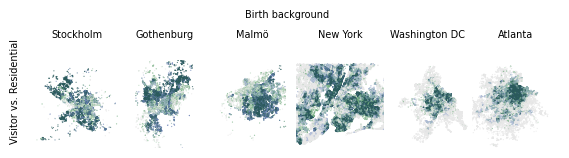

In [56]:
fig1 = plot_birth_bivariate_row(
    "residential_entropy_birth_norm",
    "Visitor vs. Residential",
    selected_cities,
    all_pois
)

fig1.savefig(
    "outputs/figures/fig1_mixing_overview_c.pdf",
    dpi=600,
    facecolor="white"
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


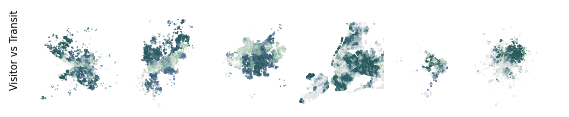

In [57]:
fig1 = plot_birth_bivariate_row(
    'catchment_entropy_birth_norm',
    'Visitor vs Transit',
    selected_cities,
    all_pois,
    show_city_labels=False,
    show_title=False
)

fig1.savefig(
    "outputs/figures/fig1_mixing_overview_c_transit.pdf",
    dpi=600,
    facecolor="white"
)

### Income

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


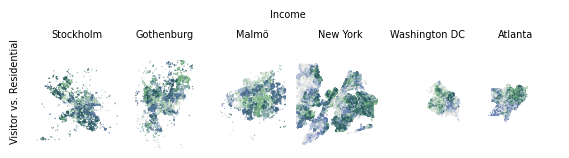

In [58]:
fig1 = plot_birth_bivariate_row(
    "residential_entropy_income_norm",
    "Visitor vs. Residential",
    selected_cities,
    all_pois,
    title_lb="Income",
)

fig1.savefig(
    "outputs/figures/fig1_mixing_overview_d.pdf",
    dpi=600,
    facecolor="white"
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


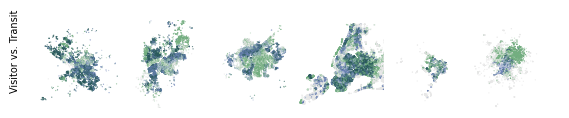

In [59]:
fig1 = plot_birth_bivariate_row(
    "catchment_entropy_income_norm",
    "Visitor vs. Transit",
    selected_cities,
    all_pois,
    show_city_labels=False,
    show_title=False
)

fig1.savefig(
    "outputs/figures/fig1_mixing_overview_d_transit.pdf",
    dpi=600,
    facecolor="white"
)

## Table 1 Spatial Clustering (Moran's I + LISA Summary) - Combined

In [7]:
# Table 1-Full: Spatial Clustering for ALL 12 Cities (Moran's I + LISA)
# N POIs from source data (filtered: valid visitor + catchment entropy)
# Moran's I and LISA percentages from lisa_summary.csv

import pandas as pd

# Get TRUE POI counts from source data (with analysis-ready filter)
us_pois_src = pd.read_parquet('dbs/routing/us_poi_diversity_metrics.parquet')
sweden_pois_src = pd.read_parquet('dbs/routing/sweden_poi_diversity_metrics.parquet')

# Filter: must have both visitor and catchment diversity
us_filtered = us_pois_src[
    us_pois_src['visitor_entropy_birth_norm'].notna() & 
    us_pois_src['catchment_entropy_birth_norm'].notna()
]
sweden_filtered = sweden_pois_src[
    sweden_pois_src['visitor_entropy_birth_norm'].notna() & 
    sweden_pois_src['catchment_entropy_birth_norm'].notna()
]

# Get counts per city
poi_counts = {}
for city, count in us_filtered.groupby('city').size().items():
    poi_counts[city] = count
for city, count in sweden_filtered.groupby('city').size().items():
    poi_counts[city] = count

# Load LISA summary (has Moran's I and cluster percentages)
lisa_summary = pd.read_csv('outputs/phase2/lisa_summary.csv')

# Define the 12 cities for main analysis
TARGET_CITIES = {
    'Stockholm': 'Sweden', 'Göteborg': 'Sweden', 'Malmö': 'Sweden',
    'Uppsala': 'Sweden', 'Västerås': 'Sweden', 'Örebro': 'Sweden',
    'Linköping': 'Sweden', 'Helsingborg': 'Sweden', 'Lund': 'Sweden',
    'new_york': 'US', 'washington_dc': 'US', 'atlanta': 'US'
}

CITY_DISPLAY = {
    'Stockholm': 'Stockholm', 'Göteborg': 'Gothenburg', 'Malmö': 'Malmö',
    'Uppsala': 'Uppsala', 'Västerås': 'Västerås', 'Örebro': 'Örebro',
    'Linköping': 'Linköping', 'Helsingborg': 'Helsingborg', 'Lund': 'Lund',
    'new_york': 'New York', 'washington_dc': 'Washington DC', 'atlanta': 'Atlanta'
}

table1_data = []

for city, country in TARGET_CITIES.items():
    # Get LISA data
    lisa_birth = lisa_summary[(lisa_summary['city'] == city) & (lisa_summary['entropy_type'] == 'birth')]
    lisa_income = lisa_summary[(lisa_summary['city'] == city) & (lisa_summary['entropy_type'] == 'income')]
    
    if len(lisa_birth) == 0:
        print(f"Warning: No LISA data for {city}")
        continue
    
    row = {
        'City': CITY_DISPLAY.get(city, city),
        'Country': country,
        'N POIs': poi_counts.get(city, 0),
        # Birth dimension - Moran's I from lisa_summary
        "Moran's I (Birth)": lisa_birth['global_moran_i'].values[0],
        'HH% (Birth)': lisa_birth['pct_high_high'].values[0],
        'LL% (Birth)': lisa_birth['pct_low_low'].values[0],
        # Income dimension
        "Moran's I (Income)": lisa_income['global_moran_i'].values[0] if len(lisa_income) > 0 else None,
        'HH% (Income)': lisa_income['pct_high_high'].values[0] if len(lisa_income) > 0 else None,
        'LL% (Income)': lisa_income['pct_low_low'].values[0] if len(lisa_income) > 0 else None,
    }
    table1_data.append(row)

table1_full = pd.DataFrame(table1_data)

# Sort: Sweden first (alphabetically), then US (by size)
table1_full['sort_key'] = table1_full.apply(
    lambda r: (0, r['City']) if r['Country'] == 'Sweden' else (1, -r['N POIs']), axis=1
)
table1_full = table1_full.sort_values('sort_key').drop(columns='sort_key')

# Display formatted
print("Table 1: Spatial Clustering Summary (Full 12 Cities)")
print("=" * 120)
display_df = table1_full.copy()
display_df['N POIs'] = display_df['N POIs'].apply(lambda x: f"{x:,}")
for col in display_df.columns:
    if "Moran" in col:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else '-')
    elif '%' in col:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else '-')
print(display_df.to_string(index=False))

# Save
table1_full.to_csv(TABLE_DIR / 'table1_full_spatial_clustering.csv', index=False)
print(f"Saved: {TABLE_DIR / 'table1_full_spatial_clustering.csv'}")


Table 1: Spatial Clustering Summary (Full 12 Cities)
         City Country  N POIs Moran's I (Birth) HH% (Birth) LL% (Birth) Moran's I (Income) HH% (Income) LL% (Income)
   Gothenburg  Sweden  15,589             0.238       12.1%        8.8%              0.078        10.0%         3.3%
  Helsingborg  Sweden   4,696             0.167       12.2%        9.5%              0.079         6.4%         1.1%
    Linköping  Sweden   4,355             0.196        7.7%        9.4%              0.174        11.8%         5.1%
         Lund  Sweden   4,687             0.080        6.6%        5.8%              0.099         9.0%         2.8%
        Malmö  Sweden  11,822             0.203       12.6%       11.4%              0.050         9.4%         3.6%
    Stockholm  Sweden  35,323             0.127        7.9%        6.7%              0.075         9.0%         5.5%
      Uppsala  Sweden   6,936             0.171       12.1%        9.0%              0.069        11.1%         2.5%
     Väster

---
# SECTION 2: Transit Catchment Effects (Spatial Regression Analysis)

Examining how transit catchment diversity predicts visitor diversity.

In [10]:
spillover_birth['city'] = spillover_birth['city'].apply(lambda x: x.split(' - ')[-1] if ' - ' in x else x)
spillover_income['city'] = spillover_income['city'].apply(lambda x: x.split(' - ')[-1] if ' - ' in x else x)

Saved: outputs/figures/fig3_regression_coefficients.pdf
Saved: outputs/figures/fig3_regression_coefficients.png


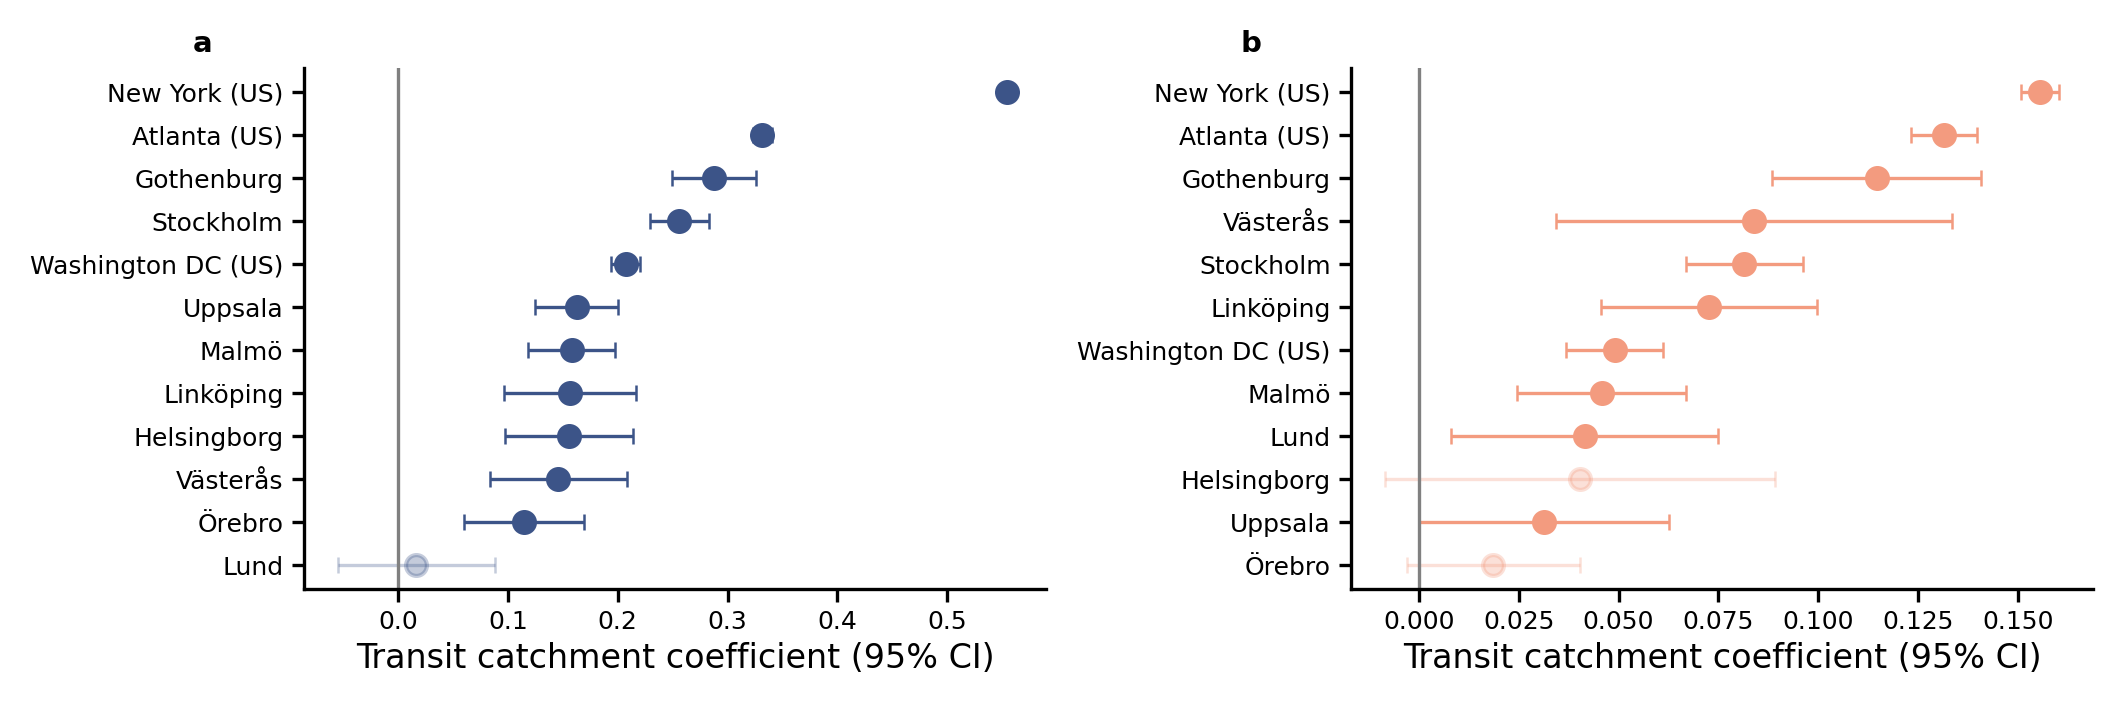

In [11]:
# Figure 3: Coefficient Comparison with Uncertainty
# Show transit catchment coefficients from OLS across cities
# Lighter color for non-significant coefficients (p >= 0.05)

fig, axes = plt.subplots(1, 2, figsize=(mm_to_inch(180), mm_to_inch(60)), dpi=300)

def get_alpha(p):
    """Return alpha value based on significance."""
    return 1.0 if p < 0.05 else 0.3

# Panel (a): Birth dimension
ax = axes[0]
plot_data = spillover_birth.copy()
plot_data['display_name'] = plot_data['city'].apply(
    lambda x: f"{CITY_DISPLAY.get(x, x)} (US)" if x in US_CITIES else CITY_DISPLAY.get(x, x)
)
plot_data['country'] = plot_data['city'].apply(lambda x: 'US' if x in US_CITIES else 'Sweden')
plot_data = plot_data.sort_values('ols_catchment_coef', ascending=True).reset_index(drop=True)

y_pos = np.arange(len(plot_data))

# Plot each point individually with alpha based on significance
for i, (_, row) in enumerate(plot_data.iterrows()):
    alpha = get_alpha(row['ols_catchment_p'])
    ax.errorbar(row['ols_catchment_coef'], i, 
                xerr=row['ols_catchment_se'] * 1.96,
                fmt='o', markersize=5, color=COLORS['birth'],
                capsize=2, capthick=0.6, elinewidth=0.8, alpha=alpha)

ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data['display_name'], color='black')
ax.set_xlabel('Transit catchment coefficient (95% CI)')
ax.text(-0.15, 1.02, 'a', transform=ax.transAxes, fontweight='bold', va='bottom')

# Panel (b): Income dimension
ax = axes[1]
plot_data = spillover_income.copy()
plot_data['display_name'] = plot_data['city'].apply(
    lambda x: f"{CITY_DISPLAY.get(x, x)} (US)" if x in US_CITIES else CITY_DISPLAY.get(x, x)
)
plot_data['country'] = plot_data['city'].apply(lambda x: 'US' if x in US_CITIES else 'Sweden')
plot_data = plot_data.sort_values('ols_catchment_coef', ascending=True).reset_index(drop=True)

y_pos = np.arange(len(plot_data))

for i, (_, row) in enumerate(plot_data.iterrows()):
    alpha = get_alpha(row['ols_catchment_p'])
    ax.errorbar(row['ols_catchment_coef'], i,
                xerr=row['ols_catchment_se'] * 1.96,
                fmt='o', markersize=5, color=COLORS['income'],
                capsize=2, capthick=0.6, elinewidth=0.8, alpha=alpha)

ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data['display_name'], color='black')
ax.set_xlabel('Transit catchment coefficient (95% CI)')
ax.text(-0.15, 1.02, 'b', transform=ax.transAxes, fontweight='bold', va='bottom')

plt.tight_layout()
save_figure(fig, 'fig3_regression_coefficients')
plt.show()

In [12]:
# Table 2: Model Performance (OLS and Spatial Lag Models)
# Long format: one row per city-dimension, showing OLS, W1, W2 results

def sig_marker(p):
    if pd.isna(p): return ''
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return ''

table2_data = []

for dim, df in [('Birth', spillover_birth), ('Income', spillover_income)]:
    for _, row in df.iterrows():
        city = row['city']

        table2_data.append({
            'City': CITY_DISPLAY.get(city, city),
            'Country': 'US' if city in US_CITIES else 'Sweden',
            'Dim': dim,
            'N': int(row['n']),
            'OLS R²': row['ols_r2'],
            'W1 ρ': row['w1_rho'],
            'W1 ρ_p': row['w1_rho_p'],
            'W1 R²': row['w1_pr2'],
            'W2 ρ': row['w2_rho'],
            'W2 ρ_p': row['w2_rho_p'],
            'W2 R²': row['w2_pr2'],
        })

table2 = pd.DataFrame(table2_data)
table2 = table2.sort_values(['Country', 'City', 'Dim'], ascending=[True, True, True])

# Display with formatting
print("Table 2: Model Performance (OLS and Spatial Lag Models)")
print("=" * 110)
print(f"{'City':<20} {'Dim':<6} {'N':>10} | {'OLS R²':>8} | {'W1 ρ':>12} {'W1 R²':>8} | {'W2 ρ':>12} {'W2 R²':>8}")
print("-" * 110)

for _, row in table2.iterrows():
    city_label = row['City'] if row['Dim'] == 'Birth' else ''
    n_str = f"{row['N']:,}" if row['Dim'] == 'Birth' else ''

    ols_r2 = f"{row['OLS R²']:.3f}" if pd.notna(row['OLS R²']) else '-'

    w1_rho = f"{row['W1 ρ']:.3f}{sig_marker(row['W1 ρ_p'])}" if pd.notna(row['W1 ρ']) else '-'
    w1_r2 = f"{row['W1 R²']:.3f}" if pd.notna(row['W1 R²']) else '-'

    w2_rho = f"{row['W2 ρ']:.3f}{sig_marker(row['W2 ρ_p'])}" if pd.notna(row['W2 ρ']) else '-'
    w2_r2 = f"{row['W2 R²']:.3f}" if pd.notna(row['W2 R²']) else '-'

    print(f"{city_label:<20} {row['Dim']:<6} {n_str:>10} | {ols_r2:>8} | {w1_rho:>12} {w1_r2:>8} | {w2_rho:>12} {w2_r2:>8}")

print("\n*** p<0.001, ** p<0.01, * p<0.05")

# Save (drop p-value columns for cleaner CSV)
table2_save = table2.drop(columns=['W1 ρ_p', 'W2 ρ_p'])
table2_save.to_csv(TABLE_DIR / 'table2_model_performance.csv', index=False)
print(f"\nSaved: {TABLE_DIR / 'table2_model_performance.csv'}")

Table 2: Model Performance (OLS and Spatial Lag Models)
City                 Dim             N |   OLS R² |         W1 ρ    W1 R² |         W2 ρ    W2 R²
--------------------------------------------------------------------------------------------------------------
Gothenburg           Birth       7,100 |    0.143 |     0.696***    0.191 |        0.023    0.147
                     Income            |    0.019 |       0.608*    0.028 |       -0.001    0.019
Helsingborg          Birth       2,108 |    0.082 |     0.701***    0.108 |        0.043    0.085
                     Income            |    0.009 |        0.937    0.024 |       -0.002    0.009
Linköping            Birth       1,914 |    0.068 |     0.835***    0.102 |       -0.054    0.061
                     Income            |    0.072 |     1.153***    0.108 |        0.004    0.072
Lund                 Birth       1,941 |    0.016 |       0.505*    0.021 |        0.014    0.016
                     Income            |    0.015

In [12]:
# Appendix Table: Full Regression Results
# Save complete regression table for appendix

appendix_data = []

for _, row in spillover_birth.iterrows():
    city = row['city']
    appendix_data.append({
        'City': CITY_DISPLAY.get(city, city),
        'Country': 'US' if city in US_CITIES else 'Sweden',
        'Entropy Type': 'Birth',
        'N': int(row['n']),
        'OLS R2': row['ols_r2'],
        'Catchment Coef': row['ols_catchment_coef'],
        'Catchment SE': row['ols_catchment_se'],
        'Catchment t': row['ols_catchment_t'],
        'Catchment p': row['ols_catchment_p'],
        'W1 rho': row['w1_rho'],
        'W1 rho SE': row['w1_rho_se'],
        'W1 Pseudo-R2': row['w1_pr2'],
        'W2 rho': row['w2_rho'],
        'W2 Pseudo-R2': row['w2_pr2'],
    })

for _, row in spillover_income.iterrows():
    city = row['city']
    appendix_data.append({
        'City': CITY_DISPLAY.get(city, city),
        'Country': 'US' if city in US_CITIES else 'Sweden',
        'Entropy Type': 'Income',
        'N': int(row['n']),
        'OLS R2': row['ols_r2'],
        'Catchment Coef': row['ols_catchment_coef'],
        'Catchment SE': row['ols_catchment_se'],
        'Catchment t': row['ols_catchment_t'],
        'Catchment p': row['ols_catchment_p'],
        'W1 rho': row['w1_rho'],
        'W1 rho SE': row['w1_rho_se'],
        'W1 Pseudo-R2': row['w1_pr2'],
        'W2 rho': row['w2_rho'],
        'W2 Pseudo-R2': row['w2_pr2'],
    })

appendix_table = pd.DataFrame(appendix_data)
appendix_table.to_csv(TABLE_DIR / 'appendix_full_regression.csv', index=False)
print(f"Saved: {TABLE_DIR / 'appendix_full_regression.csv'}")

Saved: outputs/tables/appendix_full_regression.csv


---
# SECTION 3: Spatially Uneven Effects of Transit Catchments on Social Mixing

GWR reveals where transit catchment effects are strongest and where they are weakest.

Saved: outputs/figures/fig4_gwr_birth_maps.pdf
Saved: outputs/figures/fig4_gwr_birth_maps.png


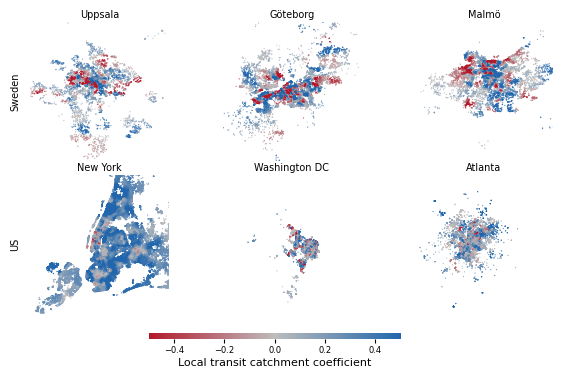

In [7]:
# Figure 4: GWR Coefficient Maps
# Show spatial distribution of local coefficients (birth background only)
# All coefficients are shown; significance is ignored
# Coordinates are projected to EPSG:3857 for plotting

from matplotlib.colors import TwoSlopeNorm
from shapely.geometry import box

CITY_TO_SLUG = {
    "Stockholm": "sweden_stockholm",
    "Göteborg": "sweden_göteborg",
    "Malmö": "sweden_malmö",
    "Uppsala": "sweden_uppsala",
    "Helsingborg": "sweden_helsingborg",
    "Lund": "sweden_lund",
    "Västerås": "sweden_västerås",
    "Örebro": "sweden_örebro",
    "Linköping": "sweden_linköping",
    "New York": "us_new_york",
    "Washington DC": "us_washington_dc",
    "Atlanta": "us_atlanta",
}

CITY_TO_BOUNDS_KEY = {
    "Stockholm": "Stockholm",
    "Göteborg": "Göteborg",
    "Malmö": "Malmö",
    "Uppsala": "Uppsala",
    "Helsingborg": "Helsingborg",
    "Lund": "Lund",
    "Västerås": "Västerås",
    "Örebro": "Örebro",
    "Linköping": "Linköping",
    "New York": "new_york",
    "Washington DC": "washington_dc",
    "Atlanta": "atlanta",
}

CITY_LABELS = {
    "Stockholm": "Stockholm",
    "Göteborg": "Göteborg",
    "Malmö": "Malmö",
    "Uppsala": "Uppsala",
    "Helsingborg": "Helsingborg",
    "Lund": "Lund",
    "Västerås": "Västerås",
    "Örebro": "Örebro",
    "Linköping": "Linköping",
    "New York": "New York",
    "Washington DC": "Washington DC",
    "Atlanta": "Atlanta",
}


def get_city_slug(city):
    return CITY_TO_SLUG.get(city, city.lower().replace(" ", "_"))


def get_bounds_key(city):
    return CITY_TO_BOUNDS_KEY.get(city, city)


def city_bounds_to_3857(city, city_bounds):
    """
    Convert city bounds from (lat_min, lat_max, lon_min, lon_max) in EPSG:4326
    to (x_min, x_max, y_min, y_max) in EPSG:3857.
    """
    bounds_key = get_bounds_key(city)
    bounds = city_bounds.get(bounds_key)
    if bounds is None:
        return None

    lat_min, lat_max, lon_min, lon_max = bounds

    bbox_gdf = gpd.GeoDataFrame(
        geometry=[box(lon_min, lat_min, lon_max, lat_max)],
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    x_min, y_min, x_max, y_max = bbox_gdf.total_bounds
    return x_min, x_max, y_min, y_max


def load_gwr_birth_data(city, coef_dir, city_bounds):
    """
    Load GWR coefficient data for one city (birth background), preferring the
    pooled '_birth_all.parquet' file. Falls back to by-category birth files if
    the pooled file is unavailable. Data are filtered to city bounds and
    projected to EPSG:3857.
    """
    city_slug = get_city_slug(city)
    all_file = coef_dir / f"{city_slug}_birth_all.parquet"

    if all_file.exists():
        df = pd.read_parquet(all_file)
    else:
        pattern = f"{city_slug}_birth_*.parquet"
        matching_files = [
            f for f in coef_dir.glob(pattern)
            if not f.name.endswith("_birth_all.parquet")
        ]
        if not matching_files:
            return gpd.GeoDataFrame()

        df = pd.concat([pd.read_parquet(f) for f in matching_files], ignore_index=True)

    bounds_key = get_bounds_key(city)
    bounds = city_bounds.get(bounds_key)
    if bounds is not None:
        lat_min, lat_max, lon_min, lon_max = bounds
        df = df[
            (df["lat"] >= lat_min) & (df["lat"] <= lat_max) &
            (df["lon"] >= lon_min) & (df["lon"] <= lon_max)
        ].copy()

    if df.empty:
        return gpd.GeoDataFrame()

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    gdf["x"] = gdf.geometry.x
    gdf["y"] = gdf.geometry.y
    return gdf


def plot_gwr_birth_map(
    ax,
    city,
    coef_dir,
    city_bounds,
    vmin=-0.5,
    vmax=0.5,
    point_size=0.8,
    alpha=0.75,
):
    """
    Plot GWR local catchment coefficients for birth background in EPSG:3857.
    All coefficients are shown with the RdBu colormap; significance is ignored.
    """
    gdf = load_gwr_birth_data(city, coef_dir, city_bounds)

    if gdf.empty:
        ax.text(
            0.5, 0.5, "No data",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.axis("off")
        return None

    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    coef_vals = gdf["beta_catchment"].clip(vmin, vmax)
    cmap = red_gray_blue()
    ax.scatter(
        gdf["x"],
        gdf["y"],
        c=coef_vals,
        cmap=cmap,
        norm=norm,
        s=point_size,
        alpha=alpha,
        linewidths=0,
        rasterized=True,
    )

    extent = city_bounds_to_3857(city, city_bounds)
    if extent is not None:
        x_min, x_max, y_min, y_max = extent
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

    ax.set_box_aspect(1)
    ax.axis("off")

    return {"n_total": len(gdf)}


def add_rowwise_city_labels(fig, axes, city_grid, y_offset=0.006):
    """
    Put each city's label above its own panel.
    Labels within each row are aligned on the same horizontal line.
    """
    nrows, ncols = axes.shape

    for row_idx in range(nrows):
        row_axes = axes[row_idx, :]
        y_row = max(ax.get_position().y1 for ax in row_axes) + y_offset

        for col_idx in range(ncols):
            ax = axes[row_idx, col_idx]
            city = city_grid[row_idx][col_idx]
            bbox = ax.get_position()
            x_center = bbox.x0 + bbox.width / 2

            fig.text(
                x_center,
                y_row,
                CITY_LABELS.get(city, city),
                ha="center",
                va="bottom",
            )


def plot_gwr_birth_grid(
    sweden_cities,
    us_cities,
    coef_dir,
    city_bounds,
    title="",
    row_labels=("Sweden", "US"),
    vmin=-0.5,
    vmax=0.5,
):
    """
    Plot a 2x3 grid of GWR coefficient maps for birth background.
    All coefficients are shown; significance is ignored.
    """
    if len(sweden_cities) != 3 or len(us_cities) != 3:
        raise ValueError("Provide exactly 3 Swedish cities and 3 US cities.")

    city_grid = [sweden_cities, us_cities]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(mm_to_inch(160), mm_to_inch(100)),
        constrained_layout=False,
    )
    axes = np.atleast_2d(axes)

    if title:
        fig.text(
            0.5, 0.95,
            title,
            ha="center",
            va="top"
        )

    for row_idx, row_cities in enumerate(city_grid):
        for col_idx, city in enumerate(row_cities):
            ax = axes[row_idx, col_idx]
            plot_gwr_birth_map(
                ax=ax,
                city=city,
                coef_dir=coef_dir,
                city_bounds=city_bounds,
                vmin=vmin,
                vmax=vmax,
            )

    plt.subplots_adjust(
        left=0.07,
        right=0.985,
        bottom=0.12,
        top=0.86,
        wspace=0,
        hspace=0.1,
    )

    add_rowwise_city_labels(
        fig=fig,
        axes=axes,
        city_grid=city_grid,
        y_offset=0.006,
    )

    for row_idx, row_label in enumerate(row_labels):
        bbox = axes[row_idx, 0].get_position()
        fig.text(
            0.08,
            bbox.y0 + bbox.height / 2,
            row_label,
            ha="left",
            va="center",
            rotation=90
        )

    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    cmap = red_gray_blue()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cax = fig.add_axes([0.30, 0.055, 0.40, 0.016])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label("Local transit catchment coefficient")
    cbar.ax.tick_params()
    cbar.outline.set_visible(False)
    for spine in cax.spines.values():
        spine.set_visible(False)

    return fig


# Generate figure
sweden_cities = ["Uppsala", "Göteborg", "Malmö"]
us_cities = ["New York", "Washington DC", "Atlanta"]

fig = plot_gwr_birth_grid(
    sweden_cities=sweden_cities,
    us_cities=us_cities,
    coef_dir=coef_dir,
    city_bounds=CITY_BOUNDS,
    vmin=-0.5,
    vmax=0.5,
)

save_figure(fig, "fig4_gwr_birth_maps")
plt.show()

In [60]:
# Table 3: GWR Summary Statistics (All POIs)
# Uses only the 'all' category results (not by-category)

# Filter to 'all' category only
gwr_all = gwr_df[gwr_df['venue_category'] == 'all'].copy()
coef_all = coef_df[coef_df['venue_category'] == 'all'].copy()

if len(gwr_all) == 0:
    print("ERROR: No 'all' category results found. Run GWR with --category all first.")
else:
    table3_data = []

    for entropy in ['birth', 'income']:
        subset = gwr_all[gwr_all['entropy_type'] == entropy]
        coef_subset = coef_all[coef_all['entropy_type'] == entropy]
        
        for _, row in subset.iterrows():
            city = row['city']
            city_coefs = coef_subset[coef_subset['city'] == city]['beta_catchment']
            
            # Get simplified city name
            simple_city = city.replace('Sweden - ', '').replace('US - ', '')
            
            table3_data.append({
                'City': CITY_DISPLAY.get(simple_city, simple_city),
                'Country': 'US' if 'US' in city else 'Sweden',
                'Dimension': entropy.capitalize(),
                'N POIs': int(row['n']),
                'Mean Coef': city_coefs.mean(),
                'SD Coef': city_coefs.std(),
                'Min Coef': city_coefs.min(),
                'Max Coef': city_coefs.max(),
                '% Positive': 100 * (city_coefs > 0).mean(),
                '% Hotspot': row['hotspot_pct'],
                '% Coldspot': row['coldspot_pct'],
                'Mean R2': row['r2'],
            })

    table3 = pd.DataFrame(table3_data)
    table3 = table3.sort_values(['Dimension', 'Country', 'N POIs'], ascending=[True, True, False])

    # Display
    print("Table 3: GWR Summary - Spatial Heterogeneity (All POIs)")
    print("=" * 140)
    display_df = table3.copy()
    display_df['N POIs'] = display_df['N POIs'].apply(lambda x: f"{x:,}")
    for col in ['Mean Coef', 'SD Coef', 'Min Coef', 'Max Coef', 'Mean R2']:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else '-')
    for col in ['% Positive', '% Hotspot', '% Coldspot']:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else '-')
    print(display_df.to_string(index=False))

    # Save
    table3.to_csv(TABLE_DIR / 'table3_gwr_summary.csv', index=False)
    print(f"Saved: {TABLE_DIR / 'table3_gwr_summary.csv'}")

Table 3: GWR Summary - Spatial Heterogeneity (All POIs)
         City Country Dimension  N POIs Mean Coef SD Coef Min Coef  Max Coef % Positive % Hotspot % Coldspot Mean R2
    Stockholm  Sweden     Birth  35,323     0.053   0.843   -7.504     2.605      58.1%      2.3%       0.6%   0.105
   Gothenburg  Sweden     Birth  15,589     0.196   0.769   -3.710     3.929      63.1%      1.8%       0.0%   0.228
        Malmö  Sweden     Birth  11,822     0.140   0.598   -2.005     3.920      60.4%      1.1%       0.2%   0.197
      Uppsala  Sweden     Birth   6,936     0.209   8.353  -71.430   687.337      62.4%      2.8%       0.4%   0.188
  Helsingborg  Sweden     Birth   4,696     0.209   0.757   -3.117     3.922      75.7%      4.1%       0.9%   0.152
         Lund  Sweden     Birth   4,687     0.013   0.543   -1.968     2.513      59.3%      0.6%       0.0%   0.085
     Västerås  Sweden     Birth   4,567     0.090   0.172   -0.711     0.701      67.4%      3.4%       0.0%   0.111
       Ö

---
## Section 3B: Category-Level Analysis

GWR was run separately by POI category. This reveals which venue types show stronger transit-mixing relationships.

In [7]:
# Load by-category GWR results (excluding 'all' category)
# This is needed for category-level analysis in Figure 6

gwr_by_category = gwr_df[~gwr_df['venue_category'].isin(['all', 'other'])].copy()
print(f"By-category GWR results: {len(gwr_by_category)} runs")
print(f"Categories: {gwr_by_category['venue_category'].unique().tolist()}")
print(f"POIs by category:")
print(gwr_by_category.groupby('venue_category')['n'].sum().sort_values(ascending=False))

By-category GWR results: 88 runs
Categories: ['accommodation_travel', 'civic_community', 'education_higher', 'entertainment_recreation', 'food_dining']
POIs by category:
venue_category
food_dining                 135446
entertainment_recreation     28027
accommodation_travel         13986
education_higher              5853
civic_community               2198
Name: n, dtype: int64


Saved: outputs/figures/fig6_category_hotspot_rate.pdf
Saved: outputs/figures/fig6_category_hotspot_rate.png


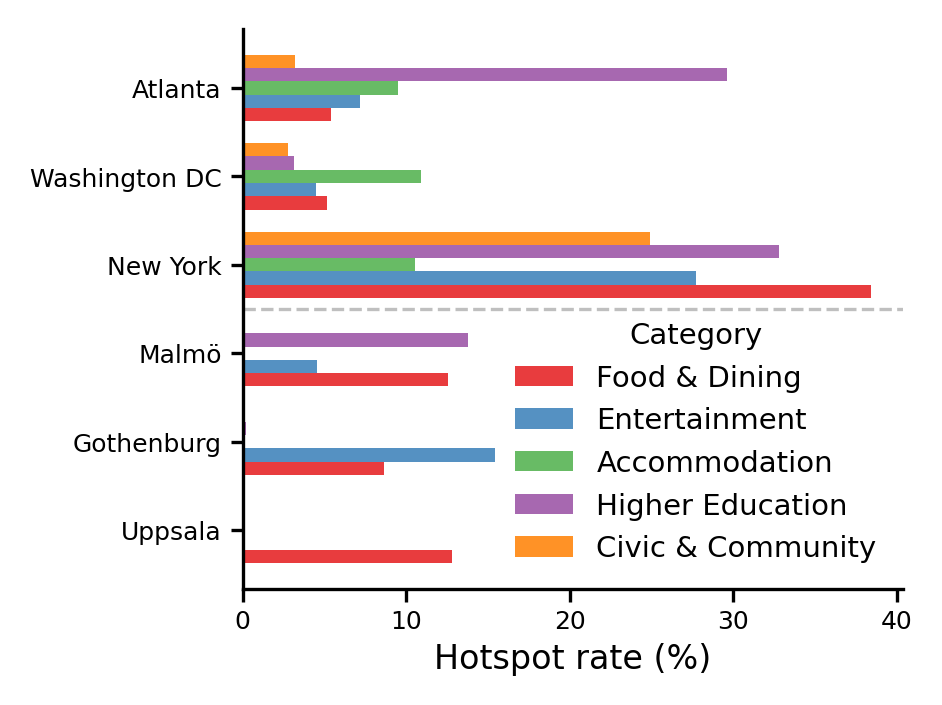


Category-level hotspot rates by city (Birth Background):
category_display  Food & Dining  Entertainment  Accommodation  Higher Education  Civic & Community
city_display                                                                                      
Uppsala                    12.8            0.0            0.0               0.0                NaN
Gothenburg                  8.7           15.4            0.0               0.2                NaN
Malmö                      12.6            4.5            0.0              13.8                NaN
New York                   38.5           27.7           10.5              32.8               24.9
Washington DC               5.2            4.5           10.9               3.2                2.7
Atlanta                     5.4            7.2            9.5              29.6                3.2


In [8]:
# Figure 6: Hotspot Rate by POI Category (Birth Background Only)
# Compare which venue types have highest transit-mixing potential by city

CATEGORY_DISPLAY = {
    'food_dining': 'Food & Dining',
    'entertainment_recreation': 'Entertainment',
    'accommodation_travel': 'Accommodation',
    'education_higher': 'Higher Education',
    'civic_community': 'Civic & Community',
}

CATEGORY_COLORS = {
    'Food & Dining': '#e41a1c',
    'Entertainment': '#377eb8',
    'Accommodation': '#4daf4a',
    'Higher Education': '#984ea3',
    'Civic & Community': '#ff7f00',
}

# Cities to include (order: Sweden first, then US)
CITIES_TO_PLOT = {
    'Sweden - Uppsala': 'Uppsala',
    'Sweden - Göteborg': 'Gothenburg',
    'Sweden - Malmö': 'Malmö',
    'US - new_york': 'New York',
    'US - washington_dc': 'Washington DC',
    'US - atlanta': 'Atlanta',
}

# Filter to birth, selected cities, and exclude 'other' category
birth_data = gwr_by_category[
    (gwr_by_category['entropy_type'] == 'birth') &
    (gwr_by_category['city'].isin(CITIES_TO_PLOT.keys())) &
    (gwr_by_category['venue_category'] != 'other')
].copy()

# Aggregate by city, category
category_stats = birth_data.groupby(['city', 'venue_category']).agg({
    'n': 'sum',
    'n_hotspots': 'sum',
}).reset_index()

category_stats['hotspot_pct'] = 100 * category_stats['n_hotspots'] / category_stats['n']
category_stats['category_display'] = category_stats['venue_category'].map(CATEGORY_DISPLAY)
category_stats['city_display'] = category_stats['city'].map(CITIES_TO_PLOT)

# Order cities and categories
cities_order = ['Uppsala', 'Gothenburg', 'Malmö', 'New York', 'Washington DC', 'Atlanta']
categories = list(CATEGORY_DISPLAY.values())

fig, ax = plt.subplots(figsize=(mm_to_inch(80), mm_to_inch(60)), dpi=300)

y = np.arange(len(cities_order))
n_cats = len(categories)
height = 0.15
offsets = np.linspace(-(n_cats-1)/2 * height, (n_cats-1)/2 * height, n_cats)

for i, cat in enumerate(categories):
    cat_data = category_stats[category_stats['category_display'] == cat].set_index('city_display')['hotspot_pct']
    vals = [cat_data.get(city, 0) for city in cities_order]
    ax.barh(y + offsets[i], vals, height, label=cat, color=CATEGORY_COLORS[cat], alpha=0.85)

ax.set_xlabel('Hotspot rate (%)')
ax.set_yticks(y)
ax.set_yticklabels(cities_order)
ax.legend(loc='lower right', title='Category')
ax.axvline(x=0, color='gray', linewidth=0.5)

# Add separator line between Sweden and US
ax.axhline(y=2.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
save_figure(fig, 'fig6_category_hotspot_rate')
plt.show()

print("\nCategory-level hotspot rates by city (Birth Background):")
pivot = category_stats.pivot(index='city_display', columns='category_display', values='hotspot_pct')
pivot = pivot.reindex(cities_order)[categories]
print(pivot.round(1).to_string())

---
## Section 3C: Understanding Hotspots - Why Do Some POIs Translate Transit Diversity into Visitor Diversity?

**Key question**: What distinguishes hotspots (POIs where transit catchment diversity strongly predicts visitor diversity) from non-significant POIs?

Hypotheses tested:
1. Hotspots are in areas with LIMITED transit options (transit matters MORE where scarce)
2. Hotspots are NOT necessarily high-diversity areas - they're where catchment MATTERS
3. Hotspot characteristics vary by country due to baseline transit accessibility

In [10]:
# Figure 7: What Distinguishes Hotspots?
# Compare characteristics of hotspots vs non-significant POIs
# Focus: Birth background, 6 cities, ALL-category GWR results (birth_background_all)

from scipy import stats
from scipy.stats import mannwhitneyu

# City center coordinates (lat, lon)
CITY_CENTERS = {
    'Sweden - Uppsala': (59.8588, 17.6389),
    'Sweden - Göteborg': (57.7089, 11.9746),
    'Sweden - Malmö': (55.6059, 13.0007),
    'US - new_york': (40.7143, -74.0060),
    'US - washington_dc': (38.8951, -77.0364),
    'US - atlanta': (33.7537, -84.3863),
}

CITIES_TO_ANALYZE = list(CITY_CENTERS.keys())
CITY_DISPLAY_FIG7 = {
    'Sweden - Uppsala': 'Uppsala',
    'Sweden - Göteborg': 'Gothenburg',
    'Sweden - Malmö': 'Malmö',
    'US - new_york': 'New York',
    'US - washington_dc': 'Washington DC',
    'US - atlanta': 'Atlanta',
}

cities_order = ['Uppsala', 'Gothenburg', 'Malmö', 'New York', 'Washington DC', 'Atlanta']

def haversine_km(lat1, lon1, lat2, lon2):
    """Calculate haversine distance in km."""
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def bootstrap_median_ci(data, n_boot=1000, ci=95):
    """Compute bootstrapped median and confidence interval."""
    data = data.dropna()
    if len(data) < 10:
        return np.nan, np.nan, np.nan
    medians = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        medians.append(np.median(sample))
    median = np.median(data)
    lower = np.percentile(medians, (100 - ci) / 2)
    upper = np.percentile(medians, 100 - (100 - ci) / 2)
    return median, lower, upper

# Filter to birth background, ALL-category GWR (birth_background_all), 6 cities
coef_birth = coef_df[
    (coef_df['entropy_type'] == 'birth') &
    (coef_df['venue_category'] == 'all') &
    (coef_df['city'].isin(CITIES_TO_ANALYZE))
].copy()

print(f"All-category (birth_background_all) POIs: {len(coef_birth):,}")

# Standardize poi_id for merging
coef_birth['poi_id_str'] = coef_birth['poi_id'].astype(str)
all_pois['poi_id_str'] = all_pois['poi_id'].astype(str)

# Merge with POI data
hotspot_analysis = coef_birth.merge(
    all_pois[['poi_id_str', 'lat', 'lon', 'catchment_entropy_birth_norm',
              'catchment_n_tracts', 'residential_entropy_birth_norm']],
    on='poi_id_str',
    how='left',
    suffixes=('', '_poi')
)

# Use lat/lon from coefficient file if available, else from all_pois
hotspot_analysis['lat_final'] = hotspot_analysis['lat'].fillna(hotspot_analysis['lat_poi'])
hotspot_analysis['lon_final'] = hotspot_analysis['lon'].fillna(hotspot_analysis['lon_poi'])

# Calculate distance to city center
def calc_dist_to_center(row):
    center = CITY_CENTERS.get(row['city'])
    if center and pd.notna(row['lat_final']) and pd.notna(row['lon_final']):
        return haversine_km(row['lat_final'], row['lon_final'], center[0], center[1])
    return np.nan

hotspot_analysis['dist_to_center_km'] = hotspot_analysis.apply(calc_dist_to_center, axis=1)

# Define hotspot vs non-hotspot (non-significant)
hotspot_analysis['group'] = hotspot_analysis.apply(
    lambda r: 'Hotspot' if r['is_hotspot'] else ('Coldspot' if r['is_coldspot'] else 'Non-significant'),
    axis=1
)

# Filter to hotspot and non-significant only
analysis_df = hotspot_analysis[hotspot_analysis['group'].isin(['Hotspot', 'Non-significant'])].copy()

print(f"Analysis data: {len(analysis_df):,} POIs")
print(f"Hotspots: {(analysis_df['group'] == 'Hotspot').sum():,}")
print(f"Non-significant: {(analysis_df['group'] == 'Non-significant').sum():,}")
print(f"By city:")
print(analysis_df.groupby(['city', 'group']).size().unstack(fill_value=0))


All-category (birth_background_all) POIs: 237,002
Analysis data: 234,208 POIs
Hotspots: 93,004
Non-significant: 141,204
By city:
group               Hotspot  Non-significant
city                                        
Sweden - Göteborg       274            15308
Sweden - Malmö          129            11665
Sweden - Uppsala        195             6712
US - atlanta           4168            29669
US - new_york         86396            55601
US - washington_dc     1842            22249


In [11]:
# Compute Additional Variables for Hotspot Analysis
# 1. POI density (count within 500m radius)
# 2. Distance to nearest transit stop
# 3. Visitor volume

from scipy.spatial import cKDTree
import zipfile

print("Computing additional variables...")
print("=" * 60)

# =============================================================================
# 1. POI DENSITY (count of POIs within 500m)
# =============================================================================
print("\n1. Computing POI density (500m radius)...")

# Get all POI coordinates
poi_coords = analysis_df[['lat_final', 'lon_final']].dropna()

# Convert to approximate meters (at mid-latitude ~45 deg)
# 1 degree lat ≈ 111km, 1 degree lon ≈ 111km * cos(lat)
mid_lat = poi_coords['lat_final'].median()
lat_to_m = 111000
lon_to_m = 111000 * np.cos(np.radians(mid_lat))

# Build KD-tree for fast neighbor search
coords_m = np.column_stack([
    poi_coords['lat_final'].values * lat_to_m,
    poi_coords['lon_final'].values * lon_to_m
])
tree = cKDTree(coords_m)

# Count neighbors within 500m for each POI
radius_m = 500
counts = tree.query_ball_point(coords_m, r=radius_m, return_length=True)

# Subtract 1 to exclude self
analysis_df.loc[poi_coords.index, 'poi_density_500m'] = counts - 1
print(f"  POI density computed for {len(poi_coords):,} POIs")
print(f"  Mean density: {analysis_df['poi_density_500m'].mean():.1f} POIs within 500m")

# =============================================================================
# 2. TRANSIT STOP PROXIMITY
# =============================================================================
print("\n2. Computing transit stop proximity...")

GTFS_DIR = Path('dbs/gtfs')

def load_gtfs_stops(gtfs_path):
    stops_file = gtfs_path / 'stops.txt'
    if stops_file.exists():
        stops_df = pd.read_csv(stops_file)
        if 'stop_lat' in stops_df.columns and 'stop_lon' in stops_df.columns:
            return stops_df[['stop_id', 'stop_lat', 'stop_lon']].dropna()
    for zf in gtfs_path.glob('*.zip'):
        try:
            with zipfile.ZipFile(zf, 'r') as z:
                if 'stops.txt' in z.namelist():
                    stops_df = pd.read_csv(z.open('stops.txt'))
                    if 'stop_lat' in stops_df.columns and 'stop_lon' in stops_df.columns:
                        return stops_df[['stop_id', 'stop_lat', 'stop_lon']].dropna()
        except:
            continue
    return None

def compute_nearest_stop_distance(poi_lats, poi_lons, stops_df):
    if stops_df is None or len(stops_df) == 0:
        return np.full(len(poi_lats), np.nan)

    R = 6371000  # Earth radius in meters
    poi_lat = np.radians(poi_lats)
    poi_lon = np.radians(poi_lons)
    stop_lat = np.radians(stops_df['stop_lat'].values)
    stop_lon = np.radians(stops_df['stop_lon'].values)

    min_distances = np.zeros(len(poi_lats))
    batch_size = 1000

    for i in range(0, len(poi_lats), batch_size):
        end_i = min(i + batch_size, len(poi_lats))
        batch_lat = poi_lat[i:end_i, np.newaxis]
        batch_lon = poi_lon[i:end_i, np.newaxis]

        dlat = stop_lat - batch_lat
        dlon = stop_lon - batch_lon
        a = np.sin(dlat/2)**2 + np.cos(batch_lat) * np.cos(stop_lat) * np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
        distances = R * c
        min_distances[i:end_i] = np.min(distances, axis=1)

    return min_distances

# City to GTFS mapping
city_gtfs = {
    'US - new_york': GTFS_DIR / 'new_york',
    'US - washington_dc': GTFS_DIR / 'washington_dc',
    'US - atlanta': GTFS_DIR / 'atlanta',
}
sweden_gtfs = GTFS_DIR / 'sweden_south/c_01'

# Load Swedish GTFS
sweden_stops = load_gtfs_stops(sweden_gtfs) if sweden_gtfs.exists() else None
if sweden_stops is not None:
    print(f"  Loaded {len(sweden_stops):,} Swedish transit stops")

# Compute for each city
analysis_df['dist_to_transit_m'] = np.nan

for city in CITIES_TO_ANALYZE:
    city_mask = analysis_df['city'] == city
    city_pois = analysis_df[city_mask]

    if 'Sweden' in city:
        stops_df = sweden_stops
    else:
        gtfs_path = city_gtfs.get(city)
        stops_df = load_gtfs_stops(gtfs_path) if gtfs_path and gtfs_path.exists() else None

    if stops_df is not None and len(city_pois) > 0:
        distances = compute_nearest_stop_distance(
            city_pois['lat_final'].values,
            city_pois['lon_final'].values,
            stops_df
        )
        analysis_df.loc[city_mask, 'dist_to_transit_m'] = distances
        print(f"  {CITY_DISPLAY_FIG7[city]}: {len(city_pois):,} POIs, median dist = {np.nanmedian(distances):.0f}m")

# =============================================================================
# 3. VISITOR VOLUME (using visitor_n_home_tracts as proxy)
# =============================================================================
print("\n3. Using visitor_n_home_tracts as visitor volume proxy...")

# visitor_n_home_tracts is already in all_pois - merge it
if 'visitor_n_home_tracts' not in analysis_df.columns:
    visitor_vol = all_pois[['poi_id_str', 'visitor_n_home_tracts']].drop_duplicates()
    analysis_df = analysis_df.merge(visitor_vol, on='poi_id_str', how='left', suffixes=('', '_vol'))

print(f"  Visitor volume (n_home_tracts) available for {analysis_df['visitor_n_home_tracts'].notna().sum():,} POIs")
print(f"  Median visitor volume: {analysis_df['visitor_n_home_tracts'].median():.0f} origin tracts")

# Summary
print("\n" + "=" * 60)
print("VARIABLE SUMMARY")
print("=" * 60)
for var in ['poi_density_500m', 'dist_to_transit_m', 'visitor_n_home_tracts']:
    valid = analysis_df[var].notna().sum()
    print(f"{var}: {valid:,} valid values, median = {analysis_df[var].median():.1f}")

Computing additional variables...

1. Computing POI density (500m radius)...
  POI density computed for 234,208 POIs
  Mean density: 272.6 POIs within 500m

2. Computing transit stop proximity...
  Loaded 146,769 Swedish transit stops
  Uppsala: 6,907 POIs, median dist = 124m
  Gothenburg: 15,582 POIs, median dist = 136m
  Malmö: 11,794 POIs, median dist = 132m
  New York: 141,997 POIs, median dist = 91m
  Washington DC: 24,091 POIs, median dist = 166m
  Atlanta: 33,837 POIs, median dist = 141m

3. Using visitor_n_home_tracts as visitor volume proxy...
  Visitor volume (n_home_tracts) available for 234,208 POIs
  Median visitor volume: 31 origin tracts

VARIABLE SUMMARY
poi_density_500m: 234,208 valid values, median = 129.0
dist_to_transit_m: 234,208 valid values, median = 111.1
visitor_n_home_tracts: 234,208 valid values, median = 31.0


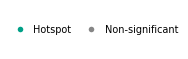

In [86]:
# Create legend elements
legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=COLORS['positive'], markeredgecolor='none',
           markersize=4, label='Hotspot'),
    
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=COLORS['nonsig'], markeredgecolor='none',
           markersize=4, label='Non-significant'),
]

# Create figure (40 mm × 10 mm)
fig, ax = plt.subplots(figsize=(mm_to_inch(40), mm_to_inch(10)))

# Remove axes
ax.axis('off')

# Add legend (horizontal, centered)
ax.legend(
    handles=legend_elements,
    loc='center',
    ncol=2,
    frameon=False,
    handletextpad=0.4,
    columnspacing=1.0,
    borderpad=0.0
)

# Tight layout
plt.tight_layout(pad=0)

# Save
fig.savefig(
    "outputs/figures/legend_hotspot.pdf",
    dpi=600,
    bbox_inches='tight',
    facecolor="white"
)

plt.show()

Mann-Whitney U Test: Distance to City Center
Uppsala: p=0.0000 ***
Gothenburg: p=0.0000 ***
Malmö: p=0.0000 ***
New York: p=0.0000 ***
Washington DC: p=0.0000 ***
Atlanta: p=0.0050 **
Saved: outputs/figures/fig7a_distance_to_center.pdf
Saved: outputs/figures/fig7a_distance_to_center.png


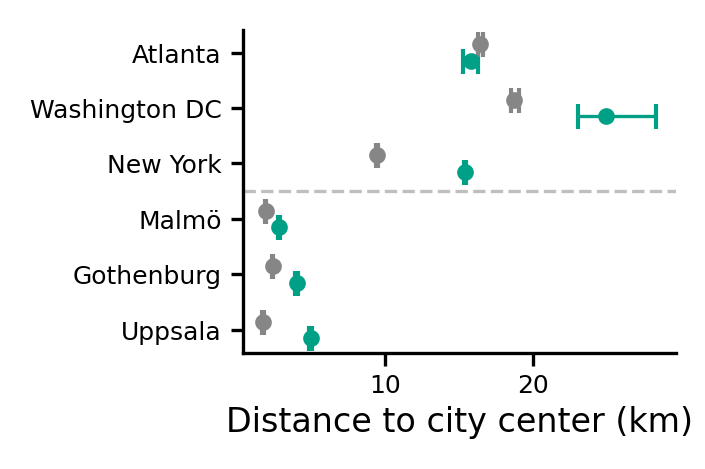

In [12]:
# Figure 7a: Distance to City Center
# Hotspot vs Non-significant POIs with Mann-Whitney U test
# Lighter colors for cities with non-significant differences

# Compute bootstrapped medians and Mann-Whitney tests
results_dist = []
mw_pvals_dist = {}

for city in CITIES_TO_ANALYZE:
    city_display = CITY_DISPLAY_FIG7[city]

    # Mann-Whitney test
    hotspot_vals = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == 'Hotspot')]['dist_to_center_km'].dropna()
    nonsig_vals = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == 'Non-significant')]['dist_to_center_km'].dropna()
    if len(hotspot_vals) > 10 and len(nonsig_vals) > 10:
        stat, pval = mannwhitneyu(hotspot_vals, nonsig_vals, alternative='two-sided')
        mw_pvals_dist[city_display] = pval
    else:
        mw_pvals_dist[city_display] = 1.0

    for group in ['Hotspot', 'Non-significant']:
        subset = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == group)]
        median, lower, upper = bootstrap_median_ci(subset['dist_to_center_km'])
        results_dist.append({
            'city': city_display,
            'group': group,
            'median': median,
            'lower': lower,
            'upper': upper,
            'n': len(subset)
        })

dist_df = pd.DataFrame(results_dist)

# Print test results
print("Mann-Whitney U Test: Distance to City Center")
print("=" * 60)
for city in cities_order:
    pval = mw_pvals_dist.get(city, 1.0)
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else '(ns)'
    print(f"{city}: p={pval:.4f} {sig}")

fig, ax = plt.subplots(figsize=(mm_to_inch(60), mm_to_inch(40)), dpi=300)

y_positions = np.arange(len(cities_order))
offset = 0.15

for i, group in enumerate(['Hotspot', 'Non-significant']):
    group_data = dist_df[dist_df['group'] == group].set_index('city')
    medians = [group_data.loc[c, 'median'] if c in group_data.index else np.nan for c in cities_order]
    lowers = [group_data.loc[c, 'lower'] if c in group_data.index else np.nan for c in cities_order]
    uppers = [group_data.loc[c, 'upper'] if c in group_data.index else np.nan for c in cities_order]

    yerr_lower = [m - l if not np.isnan(m) else 0 for m, l in zip(medians, lowers)]
    yerr_upper = [u - m if not np.isnan(m) else 0 for m, u in zip(medians, uppers)]

    base_color = COLORS['positive'] if group == 'Hotspot' else COLORS['nonsig']
    y_pos = y_positions + (i - 0.5) * offset * 2

    # Plot each city separately with appropriate alpha
    for j, city in enumerate(cities_order):
        pval = mw_pvals_dist.get(city, 1.0)
        alpha = 1.0 if pval < 0.05 else 0.3

        ax.errorbar(medians[j], y_pos[j], xerr=[[yerr_lower[j]], [yerr_upper[j]]],
                    fmt='o', color=base_color, capsize=3, markersize=3, alpha=alpha,
                    label=group if j == 0 else None)

ax.set_yticks(y_positions)
ax.set_yticklabels(cities_order)
ax.set_xlabel('Distance to city center (km)')
ax.axhline(y=2.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
save_figure(fig, 'fig7a_distance_to_center')
plt.show()

Mann-Whitney U Test: Transit Catchment Diversity
Uppsala: p=0.0000 ***
Gothenburg: p=0.6955 (ns)
Malmö: p=0.0000 ***
New York: p=0.0000 ***
Washington DC: p=0.0000 ***
Atlanta: p=0.0000 ***
Saved: outputs/figures/fig7b_catchment_diversity.pdf
Saved: outputs/figures/fig7b_catchment_diversity.png


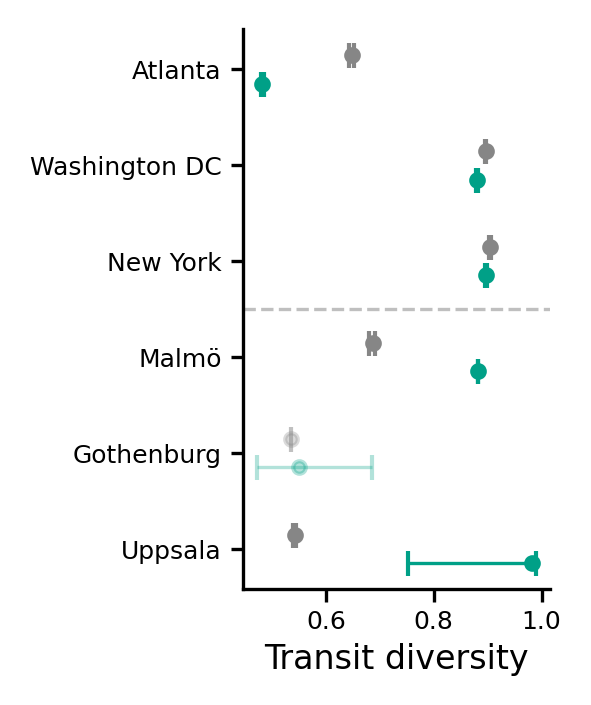

In [13]:
# Figure 7b: Transit Catchment Diversity
# Hotspot vs Non-significant POIs with Mann-Whitney U test
# Lighter colors for cities with non-significant differences

# Compute bootstrapped medians and Mann-Whitney tests
results_catch = []
mw_pvals_catch = {}

for city in CITIES_TO_ANALYZE:
    city_display = CITY_DISPLAY_FIG7[city]

    # Mann-Whitney test
    hotspot_vals = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == 'Hotspot')]['catchment_entropy_birth_norm'].dropna()
    nonsig_vals = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == 'Non-significant')]['catchment_entropy_birth_norm'].dropna()
    if len(hotspot_vals) > 10 and len(nonsig_vals) > 10:
        stat, pval = mannwhitneyu(hotspot_vals, nonsig_vals, alternative='two-sided')
        mw_pvals_catch[city_display] = pval
    else:
        mw_pvals_catch[city_display] = 1.0

    for group in ['Hotspot', 'Non-significant']:
        subset = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == group)]
        median, lower, upper = bootstrap_median_ci(subset['catchment_entropy_birth_norm'])
        results_catch.append({
            'city': city_display,
            'group': group,
            'median': median,
            'lower': lower,
            'upper': upper,
        })

catch_df = pd.DataFrame(results_catch)

# Print test results
print("Mann-Whitney U Test: Transit Catchment Diversity")
print("=" * 60)
for city in cities_order:
    pval = mw_pvals_catch.get(city, 1.0)
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else '(ns)'
    print(f"{city}: p={pval:.4f} {sig}")

fig, ax = plt.subplots(figsize=(mm_to_inch(50), mm_to_inch(60)), dpi=300)

y_positions = np.arange(len(cities_order))
offset = 0.15

for i, group in enumerate(['Hotspot', 'Non-significant']):
    group_data = catch_df[catch_df['group'] == group].set_index('city')
    medians = [group_data.loc[c, 'median'] if c in group_data.index else np.nan for c in cities_order]
    lowers = [group_data.loc[c, 'lower'] if c in group_data.index else np.nan for c in cities_order]
    uppers = [group_data.loc[c, 'upper'] if c in group_data.index else np.nan for c in cities_order]

    yerr_lower = [m - l if not np.isnan(m) else 0 for m, l in zip(medians, lowers)]
    yerr_upper = [u - m if not np.isnan(m) else 0 for m, u in zip(medians, uppers)]

    base_color = COLORS['positive'] if group == 'Hotspot' else COLORS['nonsig']
    y_pos = y_positions + (i - 0.5) * offset * 2

    # Plot each city separately with appropriate alpha
    for j, city in enumerate(cities_order):
        pval = mw_pvals_catch.get(city, 1.0)
        alpha = 1.0 if pval < 0.05 else 0.3

        ax.errorbar(medians[j], y_pos[j], xerr=[[yerr_lower[j]], [yerr_upper[j]]],
                    fmt='o', color=base_color, capsize=3, markersize=3, alpha=alpha,
                    label=group if j == 0 else None)

ax.set_yticks(y_positions)
ax.set_yticklabels(cities_order)
ax.set_xlabel('Transit diversity')
ax.axhline(y=2.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
plt.tight_layout()
save_figure(fig, 'fig7b_catchment_diversity')
plt.show()

In [ ]:
# Figure 7c: Number of Connected Tracts
# Hotspot vs Non-significant POIs with Mann-Whitney U test
# Lighter colors for cities with non-significant differences

# Compute bootstrapped medians and Mann-Whitney tests
results_tracts = []
mw_pvals_tracts = {}

for city in CITIES_TO_ANALYZE:
    city_display = CITY_DISPLAY_FIG7[city]

    # Mann-Whitney test
    hotspot_vals = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == 'Hotspot')]['catchment_n_tracts'].dropna()
    nonsig_vals = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == 'Non-significant')]['catchment_n_tracts'].dropna()
    if len(hotspot_vals) > 10 and len(nonsig_vals) > 10:
        stat, pval = mannwhitneyu(hotspot_vals, nonsig_vals, alternative='two-sided')
        mw_pvals_tracts[city_display] = pval
    else:
        mw_pvals_tracts[city_display] = 1.0

    for group in ['Hotspot', 'Non-significant']:
        subset = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == group)]
        median, lower, upper = bootstrap_median_ci(subset['catchment_n_tracts'])
        results_tracts.append({
            'city': city_display,
            'group': group,
            'median': median,
            'lower': lower,
            'upper': upper,
        })

tracts_df = pd.DataFrame(results_tracts)

# Print test results
print("Mann-Whitney U Test: Number of Connected Tracts")
print("=" * 60)
for city in cities_order:
    pval = mw_pvals_tracts.get(city, 1.0)
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else '(ns)'
    print(f"{city}: p={pval:.4f} {sig}")

fig, ax = plt.subplots(figsize=(mm_to_inch(90), mm_to_inch(60)), dpi=300)

y_positions = np.arange(len(cities_order))
offset = 0.15

for i, group in enumerate(['Hotspot', 'Non-significant']):
    group_data = tracts_df[tracts_df['group'] == group].set_index('city')
    medians = [group_data.loc[c, 'median'] if c in group_data.index else np.nan for c in cities_order]
    lowers = [group_data.loc[c, 'lower'] if c in group_data.index else np.nan for c in cities_order]
    uppers = [group_data.loc[c, 'upper'] if c in group_data.index else np.nan for c in cities_order]

    yerr_lower = [m - l if not np.isnan(m) else 0 for m, l in zip(medians, lowers)]
    yerr_upper = [u - m if not np.isnan(m) else 0 for m, u in zip(medians, uppers)]

    base_color = COLORS['positive'] if group == 'Hotspot' else COLORS['nonsig']
    y_pos = y_positions + (i - 0.5) * offset * 2

    # Plot each city separately with appropriate alpha
    for j, city in enumerate(cities_order):
        pval = mw_pvals_tracts.get(city, 1.0)
        alpha = 1.0 if pval < 0.05 else 0.3

        ax.errorbar(medians[j], y_pos[j], xerr=[[yerr_lower[j]], [yerr_upper[j]]],
                    fmt='o', color=base_color, capsize=3, markersize=3, alpha=alpha,
                    label=group if j == 0 else None)

ax.set_yticks(y_positions)
ax.set_yticklabels(cities_order)
ax.set_xlabel('Number of connected tracts')
ax.axhline(y=2.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['positive'], markersize=6, label='Hotspot'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS['nonsig'], markersize=6, label='Non-significant'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
save_figure(fig, 'fig7c_connected_tracts')
plt.show()

Mann-Whitney U Test: Residential Diversity
Uppsala: p=0.0000 ***
Gothenburg: p=0.9001 (ns)
Malmö: p=0.0000 ***
New York: p=0.0000 ***
Washington DC: p=0.0000 ***
Atlanta: p=0.0000 ***
Saved: outputs/figures/fig7d_residential_diversity.pdf
Saved: outputs/figures/fig7d_residential_diversity.png


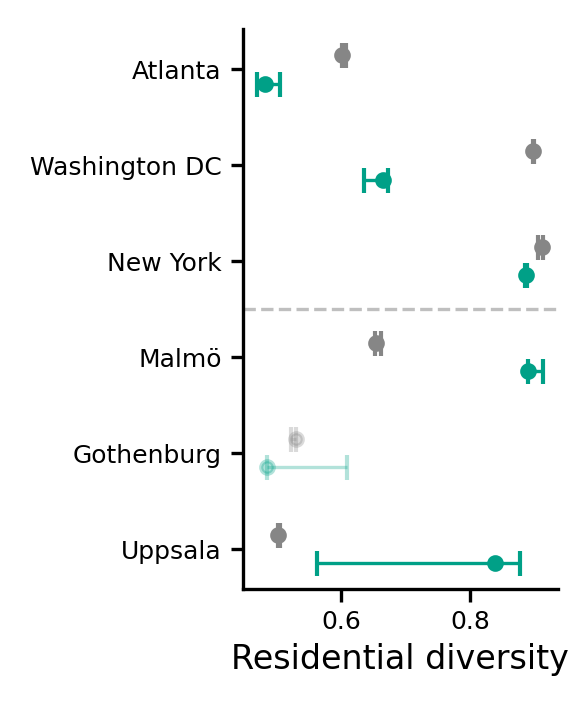

In [15]:
# Figure 7d: Residential Diversity
# Hotspot vs Non-significant POIs with Mann-Whitney U test
# Lighter colors for cities with non-significant differences

# Compute bootstrapped medians and Mann-Whitney tests
results_res = []
mw_pvals_res = {}

for city in CITIES_TO_ANALYZE:
    city_display = CITY_DISPLAY_FIG7[city]

    # Mann-Whitney test
    hotspot_vals = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == 'Hotspot')]['residential_entropy_birth_norm'].dropna()
    nonsig_vals = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == 'Non-significant')]['residential_entropy_birth_norm'].dropna()
    if len(hotspot_vals) > 10 and len(nonsig_vals) > 10:
        stat, pval = mannwhitneyu(hotspot_vals, nonsig_vals, alternative='two-sided')
        mw_pvals_res[city_display] = pval
    else:
        mw_pvals_res[city_display] = 1.0

    for group in ['Hotspot', 'Non-significant']:
        subset = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == group)]
        median, lower, upper = bootstrap_median_ci(subset['residential_entropy_birth_norm'])
        results_res.append({
            'city': city_display,
            'group': group,
            'median': median,
            'lower': lower,
            'upper': upper,
        })

res_df = pd.DataFrame(results_res)

# Print test results
print("Mann-Whitney U Test: Residential Diversity")
print("=" * 60)
for city in cities_order:
    pval = mw_pvals_res.get(city, 1.0)
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else '(ns)'
    print(f"{city}: p={pval:.4f} {sig}")

fig, ax = plt.subplots(figsize=(mm_to_inch(50), mm_to_inch(60)), dpi=300)

y_positions = np.arange(len(cities_order))
offset = 0.15

for i, group in enumerate(['Hotspot', 'Non-significant']):
    group_data = res_df[res_df['group'] == group].set_index('city')
    medians = [group_data.loc[c, 'median'] if c in group_data.index else np.nan for c in cities_order]
    lowers = [group_data.loc[c, 'lower'] if c in group_data.index else np.nan for c in cities_order]
    uppers = [group_data.loc[c, 'upper'] if c in group_data.index else np.nan for c in cities_order]

    yerr_lower = [m - l if not np.isnan(m) else 0 for m, l in zip(medians, lowers)]
    yerr_upper = [u - m if not np.isnan(m) else 0 for m, u in zip(medians, uppers)]

    base_color = COLORS['positive'] if group == 'Hotspot' else COLORS['nonsig']
    y_pos = y_positions + (i - 0.5) * offset * 2

    # Plot each city separately with appropriate alpha
    for j, city in enumerate(cities_order):
        pval = mw_pvals_res.get(city, 1.0)
        alpha = 1.0 if pval < 0.05 else 0.3

        ax.errorbar(medians[j], y_pos[j], xerr=[[yerr_lower[j]], [yerr_upper[j]]],
                    fmt='o', color=base_color, capsize=3, markersize=3, alpha=alpha,
                    label=group if j == 0 else None)

ax.set_yticks(y_positions)
ax.set_yticklabels(cities_order)
ax.set_xlabel('Residential diversity')
ax.axhline(y=2.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
save_figure(fig, 'fig7d_residential_diversity')
plt.show()

Mann-Whitney U Test: POI Density (500m)
Uppsala: p=0.0000 ***
Gothenburg: p=0.0000 ***
Malmö: p=0.0000 ***
New York: p=0.0000 ***
Washington DC: p=0.0000 ***
Atlanta: p=0.0000 ***
Saved: outputs/figures/fig7e_poi_density.pdf
Saved: outputs/figures/fig7e_poi_density.png


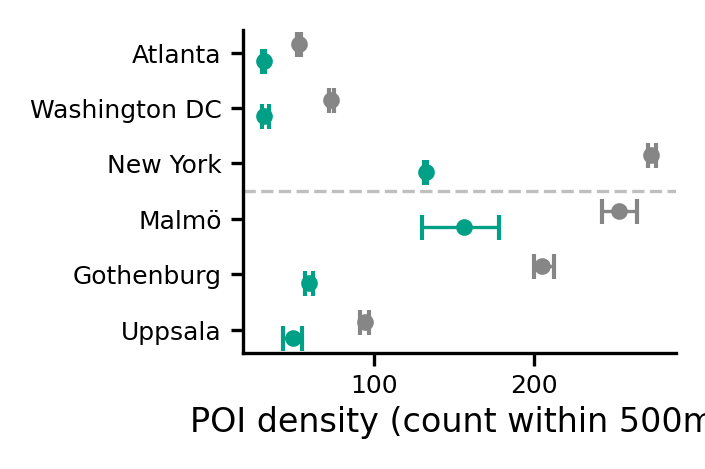

In [16]:
# Figure 7e: POI Density (500m radius)
# Hotspot vs Non-significant POIs

# Compute bootstrapped medians and Mann-Whitney tests
results_density = []
mw_pvals_density = {}

for city in CITIES_TO_ANALYZE:
    city_display = CITY_DISPLAY_FIG7[city]

    hotspot_vals = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == 'Hotspot')]['poi_density_500m'].dropna()
    nonsig_vals = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == 'Non-significant')]['poi_density_500m'].dropna()

    if len(hotspot_vals) > 10 and len(nonsig_vals) > 10:
        stat, pval = mannwhitneyu(hotspot_vals, nonsig_vals, alternative='two-sided')
        mw_pvals_density[city_display] = pval
    else:
        mw_pvals_density[city_display] = 1.0

    for group in ['Hotspot', 'Non-significant']:
        subset = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == group)]
        median, lower, upper = bootstrap_median_ci(subset['poi_density_500m'])
        results_density.append({
            'city': city_display,
            'group': group,
            'median': median,
            'lower': lower,
            'upper': upper,
        })

density_df = pd.DataFrame(results_density)

print("Mann-Whitney U Test: POI Density (500m)")
print("=" * 60)
for city in cities_order:
    pval = mw_pvals_density.get(city, 1.0)
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else '(ns)'
    print(f"{city}: p={pval:.4f} {sig}")

fig, ax = plt.subplots(figsize=(mm_to_inch(60), mm_to_inch(40)), dpi=300)

y_positions = np.arange(len(cities_order))
offset = 0.15

for i, group in enumerate(['Hotspot', 'Non-significant']):
    group_data = density_df[density_df['group'] == group].set_index('city')
    medians = [group_data.loc[c, 'median'] if c in group_data.index else np.nan for c in cities_order]
    lowers = [group_data.loc[c, 'lower'] if c in group_data.index else np.nan for c in cities_order]
    uppers = [group_data.loc[c, 'upper'] if c in group_data.index else np.nan for c in cities_order]

    yerr_lower = [m - l if not np.isnan(m) else 0 for m, l in zip(medians, lowers)]
    yerr_upper = [u - m if not np.isnan(m) else 0 for m, u in zip(medians, uppers)]

    base_color = COLORS['positive'] if group == 'Hotspot' else COLORS['nonsig']
    y_pos = y_positions + (i - 0.5) * offset * 2

    for j, city in enumerate(cities_order):
        pval = mw_pvals_density.get(city, 1.0)
        alpha = 1.0 if pval < 0.05 else 0.3
        ax.errorbar(medians[j], y_pos[j], xerr=[[yerr_lower[j]], [yerr_upper[j]]],
                    fmt='o', color=base_color, capsize=3, markersize=3, alpha=alpha)

ax.set_yticks(y_positions)
ax.set_yticklabels(cities_order)
ax.set_xlabel('POI density (count within 500m)')
ax.axhline(y=2.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
save_figure(fig, 'fig7e_poi_density')
plt.show()

Mann-Whitney U Test: Distance to Transit Stop
Uppsala: p=0.1307 (ns)
Gothenburg: p=0.0405 *
Malmö: p=0.8059 (ns)
New York: p=0.0000 ***
Washington DC: p=0.0000 ***
Atlanta: p=0.0000 ***
Saved: outputs/figures/fig7f_transit_proximity.pdf
Saved: outputs/figures/fig7f_transit_proximity.png


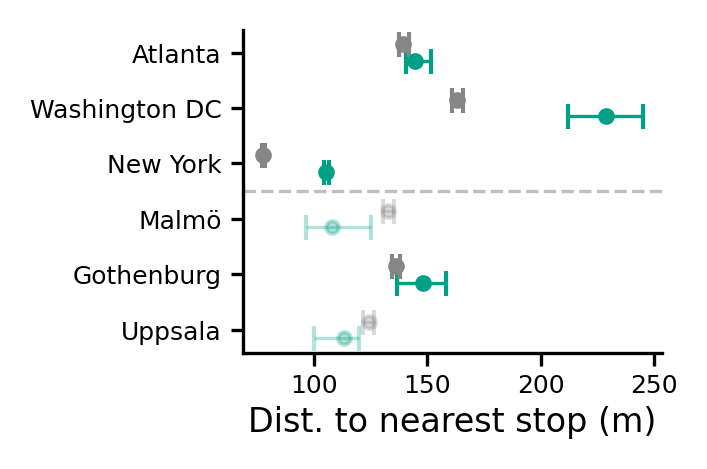

In [17]:
# Figure 7f: Distance to Nearest Transit Stop
# Hotspot vs Non-significant POIs

results_transit = []
mw_pvals_transit = {}

for city in CITIES_TO_ANALYZE:
    city_display = CITY_DISPLAY_FIG7[city]

    hotspot_vals = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == 'Hotspot')]['dist_to_transit_m'].dropna()
    nonsig_vals = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == 'Non-significant')]['dist_to_transit_m'].dropna()

    if len(hotspot_vals) > 10 and len(nonsig_vals) > 10:
        stat, pval = mannwhitneyu(hotspot_vals, nonsig_vals, alternative='two-sided')
        mw_pvals_transit[city_display] = pval
    else:
        mw_pvals_transit[city_display] = 1.0

    for group in ['Hotspot', 'Non-significant']:
        subset = analysis_df[(analysis_df['city'] == city) & (analysis_df['group'] == group)]
        median, lower, upper = bootstrap_median_ci(subset['dist_to_transit_m'])
        results_transit.append({
            'city': city_display,
            'group': group,
            'median': median,
            'lower': lower,
            'upper': upper,
        })

transit_df = pd.DataFrame(results_transit)

print("Mann-Whitney U Test: Distance to Transit Stop")
print("=" * 60)
for city in cities_order:
    pval = mw_pvals_transit.get(city, 1.0)
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else '(ns)'
    print(f"{city}: p={pval:.4f} {sig}")

fig, ax = plt.subplots(figsize=(mm_to_inch(60), mm_to_inch(40)), dpi=300)

y_positions = np.arange(len(cities_order))
offset = 0.15

for i, group in enumerate(['Hotspot', 'Non-significant']):
    group_data = transit_df[transit_df['group'] == group].set_index('city')
    medians = [group_data.loc[c, 'median'] if c in group_data.index else np.nan for c in cities_order]
    lowers = [group_data.loc[c, 'lower'] if c in group_data.index else np.nan for c in cities_order]
    uppers = [group_data.loc[c, 'upper'] if c in group_data.index else np.nan for c in cities_order]

    yerr_lower = [m - l if not np.isnan(m) else 0 for m, l in zip(medians, lowers)]
    yerr_upper = [u - m if not np.isnan(m) else 0 for m, u in zip(medians, uppers)]

    base_color = COLORS['positive'] if group == 'Hotspot' else COLORS['nonsig']
    y_pos = y_positions + (i - 0.5) * offset * 2

    for j, city in enumerate(cities_order):
        pval = mw_pvals_transit.get(city, 1.0)
        alpha = 1.0 if pval < 0.05 else 0.3
        ax.errorbar(medians[j], y_pos[j], xerr=[[yerr_lower[j]], [yerr_upper[j]]],
                    fmt='o', color=base_color, capsize=3, markersize=3, alpha=alpha)

ax.set_yticks(y_positions)
ax.set_yticklabels(cities_order)
ax.set_xlabel('Dist. to nearest stop (m)')
ax.axhline(y=2.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
save_figure(fig, 'fig7f_transit_proximity')
plt.show()

In [19]:
# Logistic Regression BY COUNTRY
# Fixed effects: distance to center, POI density, transit proximity
# NO category random effects - simple pooled logit by country
# Uses birth_background_all results

import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

# Prepare data
logit_df = analysis_df.copy()
logit_df['is_hotspot_binary'] = (logit_df['group'] == 'Hotspot').astype(int)
logit_df['country'] = logit_df['city'].apply(lambda x: 'US' if 'US' in x else 'Sweden')

# Fixed effect predictors
fixed_cols = [
    'dist_to_center_km',
    'poi_density_500m',
    'dist_to_transit_m',
]

# Clean data
logit_clean = logit_df[['is_hotspot_binary', 'country'] + fixed_cols].copy()
for col in fixed_cols:
    logit_clean[col] = pd.to_numeric(logit_clean[col], errors='coerce')
logit_clean = logit_clean.dropna()

print("=" * 80)
print("LOGISTIC REGRESSION BY COUNTRY")
print("Predictors: distance to center, POI density, transit proximity")
print("Data source: birth_background_all (pooled across all venue categories)")
print("=" * 80)

results_by_country = {}

for country in ['Sweden', 'US']:
    print(f"\n{'='*70}")
    print(f"{country}")
    print('='*70)

    country_df = logit_clean[logit_clean['country'] == country].copy()

    # Standardize numeric predictors
    means = {}
    stds = {}
    for col in fixed_cols:
        means[col] = country_df[col].mean()
        stds[col] = country_df[col].std()
        country_df[col] = (country_df[col] - means[col]) / stds[col]

    y = country_df['is_hotspot_binary'].values.astype(float)
    X = sm.add_constant(country_df[fixed_cols].values.astype(float))

    print(f"Sample size: {len(country_df):,}")
    print(f"Hotspots: {int(y.sum()):,} ({100*y.mean():.1f}%)")

    # Fit logistic regression
    print("\nFitting logistic regression...")
    model = Logit(y, X)
    result = model.fit(disp=0)

    # Fixed effects
    fixed_names = ['const'] + fixed_cols
    print(f"\nCOEFFICIENTS (standardized, 1 unit = 1 SD):")
    print("-" * 60)
    
    coefs = result.params
    ses = result.bse
    pvals = result.pvalues
    
    fixed_summary = pd.DataFrame({
        'Variable': fixed_names,
        'Coef': coefs,
        'Std Err': ses,
        'z': result.tvalues,
        'P>|z|': pvals,
        'Odds Ratio': np.exp(coefs),
        'OR 95% CI': [f"[{np.exp(m-1.96*s):.3f}, {np.exp(m+1.96*s):.3f}]"
                      for m, s in zip(coefs, ses)],
    }).set_index('Variable')
    print(fixed_summary.to_string())

    # Performance metrics
    y_pred_prob = result.predict(X)
    y_pred = (y_pred_prob > 0.5).astype(int)

    auc = roc_auc_score(y, y_pred_prob)
    acc = accuracy_score(y, y_pred)

    print(f"\nMODEL PERFORMANCE:")
    print("-" * 60)
    print(f"  Pseudo R-squared: {result.prsquared:.4f}")
    print(f"  Log-Likelihood: {result.llf:.1f}")
    print(f"  ROC-AUC: {auc:.4f}")
    print(f"  Accuracy: {acc:.4f}")

    tn, fp, fn, tp = confusion_matrix(y.astype(int), y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"  Sensitivity (TPR): {sensitivity:.3f}")
    print(f"  Specificity (TNR): {specificity:.3f}")

    # Interpretation
    print(f"\nINTERPRETATION:")
    print("-" * 60)
    for i, var in enumerate(fixed_cols):
        coef = coefs[i+1]
        se = ses[i+1]
        pval = pvals[i+1]
        or_val = np.exp(coef)
        ci_low = np.exp(coef - 1.96*se)
        ci_high = np.exp(coef + 1.96*se)
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        direction = "increases" if or_val > 1 else "decreases"
        pct = abs(or_val - 1) * 100
        print(f"  {var}: OR={or_val:.3f} [{ci_low:.3f}, {ci_high:.3f}] (1 SD {direction} odds by {pct:.1f}%) {sig}")

    results_by_country[country] = {
        'n': len(country_df),
        'hotspot_pct': 100*y.mean(),
        'pseudo_r2': result.prsquared,
        'auc': auc,
        'accuracy': acc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'fixed_summary': fixed_summary,
    }

# Comparison summary
print("\n" + "=" * 80)
print("COUNTRY COMPARISON SUMMARY")
print("=" * 80)
print(f"{'Metric':<25} {'Sweden':>15} {'US':>15}")
print("-" * 55)
print(f"{'Sample size':<25} {results_by_country['Sweden']['n']:>15,} {results_by_country['US']['n']:>15,}")
print(f"{'Hotspot %':<25} {results_by_country['Sweden']['hotspot_pct']:>15.1f} {results_by_country['US']['hotspot_pct']:>15.1f}")
print(f"{'Pseudo R-squared':<25} {results_by_country['Sweden']['pseudo_r2']:>15.4f} {results_by_country['US']['pseudo_r2']:>15.4f}")
print(f"{'ROC-AUC':<25} {results_by_country['Sweden']['auc']:>15.4f} {results_by_country['US']['auc']:>15.4f}")
print(f"{'Accuracy':<25} {results_by_country['Sweden']['accuracy']:>15.4f} {results_by_country['US']['accuracy']:>15.4f}")
print(f"{'Sensitivity':<25} {results_by_country['Sweden']['sensitivity']:>15.4f} {results_by_country['US']['sensitivity']:>15.4f}")
print(f"{'Specificity':<25} {results_by_country['Sweden']['specificity']:>15.4f} {results_by_country['US']['specificity']:>15.4f}")

print("\nODDS RATIOS COMPARISON:")
print(f"{'Predictor':<25} {'Sweden':>12} {'US':>12}")
print("-" * 50)
for pred in fixed_cols:
    se_or = results_by_country['Sweden']['fixed_summary'].loc[pred, 'Odds Ratio']
    us_or = results_by_country['US']['fixed_summary'].loc[pred, 'Odds Ratio']
    print(f"{pred:<25} {se_or:>12.3f} {us_or:>12.3f}")


LOGISTIC REGRESSION BY COUNTRY
Predictors: distance to center, POI density, transit proximity
Data source: birth_background_all (pooled across all venue categories)

Sweden
Sample size: 34,283
Hotspots: 598 (1.7%)

Fitting logistic regression...

COEFFICIENTS (standardized, 1 unit = 1 SD):
------------------------------------------------------------
                       Coef   Std Err          z         P>|z|  Odds Ratio       OR 95% CI
Variable                                                                                  
const             -4.183398  0.048820 -85.689458  0.000000e+00    0.015247  [0.014, 0.017]
dist_to_center_km  0.040404  0.014241   2.837166  4.551592e-03    1.041231  [1.013, 1.071]
poi_density_500m  -0.614044  0.061212 -10.031416  1.109149e-23    0.541158  [0.480, 0.610]
dist_to_transit_m -0.070936  0.040453  -1.753530  7.951100e-02    0.931521  [0.861, 1.008]

MODEL PERFORMANCE:
------------------------------------------------------------
  Pseudo R-squared: 0

In [20]:
# Table: Logistic Regression Results (Manuscript Format)
# Predicting Hotspot Status by Country

print("=" * 90)
print("TABLE: Logistic Regression Predicting Transit-Mixing Hotspots")
print("=" * 90)

var_labels = {
    'dist_to_center_km': 'Distance to center (km)',
    'poi_density_500m': 'POI density (500m)',
    'dist_to_transit_m': 'Transit proximity (m)',
}

# Build LaTeX table
latex_lines = []
latex_lines.append(r"\begin{table}[htbp]")
latex_lines.append(r"\centering")
latex_lines.append(r"\caption{Logistic Regression Predicting Transit-Mixing Hotspots}")
latex_lines.append(r"\label{tab:logit_hotspot}")
latex_lines.append(r"\small")
latex_lines.append(r"\begin{tabular}{lcccc}")
latex_lines.append(r"\toprule")
latex_lines.append(r" & \multicolumn{2}{c}{Sweden} & \multicolumn{2}{c}{United States} \\")
latex_lines.append(r"\cmidrule(lr){2-3} \cmidrule(lr){4-5}")
latex_lines.append(r"Variable & OR [95\% CI] & & OR [95\% CI] & \\")
latex_lines.append(r"\midrule")

for var in fixed_cols:
    label = var_labels.get(var, var)

    # Sweden
    se_coef = results_by_country['Sweden']['fixed_summary'].loc[var, 'Coef']
    se_se = results_by_country['Sweden']['fixed_summary'].loc[var, 'Std Err']
    se_or = results_by_country['Sweden']['fixed_summary'].loc[var, 'Odds Ratio']
    se_pval = results_by_country['Sweden']['fixed_summary'].loc[var, 'P>|z|']
    se_ci_low = np.exp(se_coef - 1.96 * se_se)
    se_ci_high = np.exp(se_coef + 1.96 * se_se)
    se_sig = '***' if se_pval < 0.001 else '**' if se_pval < 0.01 else '*' if se_pval < 0.05 else ''

    # US
    us_coef = results_by_country['US']['fixed_summary'].loc[var, 'Coef']
    us_se = results_by_country['US']['fixed_summary'].loc[var, 'Std Err']
    us_or = results_by_country['US']['fixed_summary'].loc[var, 'Odds Ratio']
    us_pval = results_by_country['US']['fixed_summary'].loc[var, 'P>|z|']
    us_ci_low = np.exp(us_coef - 1.96 * us_se)
    us_ci_high = np.exp(us_coef + 1.96 * us_se)
    us_sig = '***' if us_pval < 0.001 else '**' if us_pval < 0.01 else '*' if us_pval < 0.05 else ''

    latex_lines.append(f"\quad {label} & {se_or:.3f} [{se_ci_low:.3f}, {se_ci_high:.3f}]{se_sig} & & {us_or:.3f} [{us_ci_low:.3f}, {us_ci_high:.3f}]{us_sig} & \\\\")

latex_lines.append(r"\addlinespace[3pt]")

# Model fit
latex_lines.append(r"\textit{Model Performance} & & & & \\")
latex_lines.append(f"\quad Pseudo $R^2$ & {results_by_country['Sweden']['pseudo_r2']:.3f} & & {results_by_country['US']['pseudo_r2']:.3f} & \\\\")
latex_lines.append(f"\quad ROC-AUC & {results_by_country['Sweden']['auc']:.3f} & & {results_by_country['US']['auc']:.3f} & \\\\")
latex_lines.append(f"\quad Accuracy & {results_by_country['Sweden']['accuracy']:.3f} & & {results_by_country['US']['accuracy']:.3f} & \\\\")
latex_lines.append(f"\quad Sensitivity & {results_by_country['Sweden']['sensitivity']:.3f} & & {results_by_country['US']['sensitivity']:.3f} & \\\\")
latex_lines.append(f"\quad Specificity & {results_by_country['Sweden']['specificity']:.3f} & & {results_by_country['US']['specificity']:.3f} & \\\\")

latex_lines.append(r"\addlinespace[3pt]")
latex_lines.append(f"\quad N & {results_by_country['Sweden']['n']:,} & & {results_by_country['US']['n']:,} & \\\\")
latex_lines.append(f"\quad Hotspots (\%) & {results_by_country['Sweden']['hotspot_pct']:.1f} & & {results_by_country['US']['hotspot_pct']:.1f} & \\\\")

latex_lines.append(r"\bottomrule")
latex_lines.append(r"\end{tabular}")
latex_lines.append(r"\begin{tablenotes}")
latex_lines.append(r"\small")
latex_lines.append(r"\item Note: Odds ratios (OR) with 95\% confidence intervals. Predictors are standardized (1 unit = 1 SD).")
latex_lines.append(r"\item * p<0.05, ** p<0.01, *** p<0.001.")
latex_lines.append(r"\item Data source: birth\_background\_all GWR results (all POIs pooled).")
latex_lines.append(r"\end{tablenotes}")
latex_lines.append(r"\end{table}")

# Print LaTeX
print("\nLaTeX Table:")
print("-" * 90)
for line in latex_lines:
    print(line)

# Save to file
with open('outputs/tables/logit_hotspot_results.tex', 'w') as f:
    f.write('\n'.join(latex_lines))
print("\nSaved: outputs/tables/logit_hotspot_results.tex")

# Also save text version
with open('outputs/tables/logit_hotspot_results.txt', 'w') as f:
    f.write("LOGISTIC REGRESSION: PREDICTING TRANSIT-MIXING HOTSPOTS\n")
    f.write("=" * 70 + "\n\n")
    f.write("Data: birth_background_all (all POIs pooled, no category stratification)\n\n")
    for country in ['Sweden', 'US']:
        f.write(f"{country}:\n")
        f.write(results_by_country[country]['fixed_summary'].to_string())
        f.write(f"\n\nPseudo R-squared: {results_by_country[country]['pseudo_r2']:.4f}")
        f.write(f"\nROC-AUC: {results_by_country[country]['auc']:.4f}")
        f.write(f"\nAccuracy: {results_by_country[country]['accuracy']:.4f}\n\n")
print("Saved: outputs/tables/logit_hotspot_results.txt")


TABLE: Logistic Regression Predicting Transit-Mixing Hotspots

LaTeX Table:
------------------------------------------------------------------------------------------
\begin{table}[htbp]
\centering
\caption{Logistic Regression Predicting Transit-Mixing Hotspots}
\label{tab:logit_hotspot}
\small
\begin{tabular}{lcccc}
\toprule
 & \multicolumn{2}{c}{Sweden} & \multicolumn{2}{c}{United States} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
Variable & OR [95\% CI] & & OR [95\% CI] & \\
\midrule
\quad Distance to center (km) & 1.041 [1.013, 1.071]** & & 1.014 [1.003, 1.024]* & \\
\quad POI density (500m) & 0.541 [0.480, 0.610]*** & & 0.745 [0.737, 0.753]*** & \\
\quad Transit proximity (m) & 0.932 [0.861, 1.008] & & 1.087 [1.076, 1.099]*** & \\
\addlinespace[3pt]
\textit{Model Performance} & & & & \\
\quad Pseudo $R^2$ & 0.025 & & 0.017 & \\
\quad ROC-AUC & 0.688 & & 0.542 & \\
\quad Accuracy & 0.983 & & 0.536 & \\
\quad Sensitivity & 0.000 & & 0.240 & \\
\quad Specificity & 1.000 & & 0.789 & \\
